## Chapter 3: Convolutional GNNs: GCN and GraphSage

Introduction
This notebook demonstrates the use of Convolutional Graph Neural Networks (GCNs) and GraphSAGE for graph representation learning, leveraging the PyTorch Geometric library. To ensure compatibility with resource-limited environments, we utilize a subgraph containing only 10,000 nodes, which is less than 1% of the total nodes in the OGBN-Products dataset. The key processes covered include setting up the environment, data preparation, model definition, training, and evaluation.

### Section 1: Environment Setup

In this section, we ensure the environment is correctly configured with the necessary libraries and dependencies. We start by checking the CUDA version and PyTorch installation, followed by installing additional required libraries.

In [2]:
import os
import sys

# Enable CPU fallback for PyTorch ops that are not implemented on MPS yet.
# Restart the kernel and run from the top if torch was already imported.
torch_was_already_imported = 'torch' in sys.modules
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch

if torch_was_already_imported:
    print('Restart the kernel: torch was already imported before PYTORCH_ENABLE_MPS_FALLBACK was set.')

print(f"Apple Metal (MPS) enabled: {torch.backends.mps.is_available()}")
print(f"MPS CPU fallback enabled: {os.environ['PYTORCH_ENABLE_MPS_FALLBACK']}")

Restart the kernel: torch was already imported before PYTORCH_ENABLE_MPS_FALLBACK was set.
Apple Metal (MPS) enabled: True
MPS CPU fallback enabled: 1


In [3]:
# PyTorch version
print(torch.__version__)

2.4.1


In [4]:
%%capture
# macOS/MPS: use CPU wheels for PyG extensions; MPS support comes from PyTorch itself.
import os
import sys

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import torch

pyg_wheel_url = f"https://data.pyg.org/whl/torch-{torch.__version__.split('+')[0]}+cpu.html"
!{sys.executable} -m pip install ogb pyg-lib torch-scatter torch-sparse -f {pyg_wheel_url}
!{sys.executable} -m pip install torch-geometric

In [5]:
# import gc

import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import torch
import torch.nn.functional as F
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

def get_torch_device():
    if torch.backends.mps.is_available():
        return torch.device('mps')
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')

def pyg_aggregation_needs_cpu(aggr):
    if isinstance(aggr, str):
        return aggr == 'max'
    if isinstance(aggr, (list, tuple, set)):
        return any(pyg_aggregation_needs_cpu(item) for item in aggr)
    return aggr.__class__.__name__ == 'MaxAggregation'

def get_pyg_device_for_aggr(aggr):
    base_device = get_torch_device()
    if base_device.type == 'mps' and pyg_aggregation_needs_cpu(aggr):
        return torch.device('cpu')
    return base_device

import torch_geometric.transforms as T
from torch_geometric.data import NeighborSampler
from torch_geometric.nn import SAGEConv, GCNConv
from torch_geometric import utils, loader
from torch_geometric.utils import subgraph

from torch_geometric.nn import (
    Aggregation,
    MaxAggregation,
    MeanAggregation,
    MultiAggregation,
    SoftmaxAggregation,
    StdAggregation,
    SumAggregation,
    VarAggregation,
    LSTMAggregation
)

# importing obg datatset
from ogb.nodeproppred import PygNodePropPredDataset
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator

from pandas.core.common import flatten
import matplotlib.pyplot as plt
from collections import Counter


from tqdm import tqdm
import collections
import os.path as osp
import pandas as pd
import numpy as np
import collections

try:
    import seaborn as sns
except ImportError:
    sns = None

def plot_confusion_matrix(cm, title, cmap='Blues'):
    if sns is not None:
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap)
    else:
        plt.imshow(cm, cmap=cmap)
        plt.colorbar()
        if cm.size <= 1024:
            for (row, col), value in np.ndenumerate(cm):
                plt.text(col, row, int(value), ha='center', va='center', fontsize=6)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
# from pandas.core.common import flatten
# from scipy.special import softmax

import random

# Setting the seed
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
# torch.backends.cudnn.deterministic = True
print(f'\nSUCCESS: Apple Metal (MPS) Enabled: {torch.backends.mps.is_available()}')
print(f'MPS CPU fallback enabled: {os.environ.get("PYTORCH_ENABLE_MPS_FALLBACK")}\n')


/Users/dpatti/miniforge3/envs/gnn_env/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: dlopen(/Users/dpatti/miniforge3/envs/gnn_env/lib/python3.11/site-packages/libpyg.so, 0x0006): Library not loaded: /Library/Frameworks/Python.framework/Versions/3.11/Python
  Referenced from: <CA14ED34-FA3D-31FE-B4AD-2B2A8446B324> /Users/dpatti/miniforge3/envs/gnn_env/lib/python3.11/site-packages/libpyg.so
  Reason: tried: '/Library/Frameworks/Python.framework/Versions/3.11/Python' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/Python.framework/Versions/3.11/Python' (no such file), '/Library/Frameworks/Python.framework/Versions/3.11/Python' (no such file)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/Users/dpatti/miniforge3/envs/gnn_env/lib/python3.11/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'.


SUCCESS: Apple Metal (MPS) Enabled: True
MPS CPU fallback enabled: 1



### Section 2: Loading the Graph Data and Creating a Subgraph
In this section, we load the OGBN-Products dataset and create a subgraph consisting of 10,000 nodes. This subset of the full dataset allows us to perform experiments in environments with limited computational resources while still demonstrating the effectiveness of graph convolutional networks (GCNs) and GraphSAGE.

#### Step 1: Load the OGBN-Products Dataset
First, we will load the OGBN-Products dataset using the PyTorch Geometric library. The dataset contains product information from Amazon, where nodes represent products and edges represent co-purchasing relationships.


#### Step 2: Create a Subgraph
To create a subgraph with 10,000 nodes, we randomly select a subset of nodes from the full graph. This subset will be used for training and evaluating our models.


#### Step 3: Process Mappings for Labels and Product IDs
Next, we load and process mappings for label indices to product categories and product IDs. These mappings will help us interpret the results and visualize the data.


#### Step 4: Verify the Subgraph
Finally, we verify that the subgraph has been created correctly by checking the number of nodes and edges.


By completing these steps, we have successfully loaded the OGBN-Products dataset and created a subgraph with 10,000 nodes. This subgraph will be used in subsequent sections to train and evaluate our GCN and GraphSAGE models.

In [6]:
opt = 'GCN'

In [7]:
# Load the OGB evaluator for the dataset
evaluator = Evaluator(name='ogbn-products')

# Use MPS on macOS when available. Unsupported MPS kernels fall back to CPU
# because PYTORCH_ENABLE_MPS_FALLBACK is set before importing torch.
device = get_torch_device()

# Confirm the device.
print('Device: {}'.format(device))

Device: mps


In [8]:
# root = osp.join(osp.dirname(osp.realpath('./')), 'data', 'products')
# download and loading the obg dataset
root = osp.join(osp.dirname(osp.realpath('./')), 'content')
if opt == 'GCN':
  dataset = PygNodePropPredDataset( name='ogbn-products', root=root)
else:
  dataset = PygNodePropPredDataset( name='ogbn-products', transform=T.ToSparseTensor(), root=root)

/Users/dpatti/miniforge3/envs/gnn_env/lib/python3.11/site-packages/ogb/nodeproppred/dataset_pyg.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.data, self.slices =

In [9]:
data = dataset[0]


In [10]:
# Define the indices of nodes to include in your subset
subset_indices = torch.arange(0, 10000)  # For example, first 10,000 nodes


# Extract the subgraph corresponding to the subset
subset_edge_index, edge_attr, edge_mask = subgraph(subset_indices, data.edge_index, None, relabel_nodes=True, num_nodes=data.num_nodes, return_edge_mask=True)


# Adjust node features and labels for the subset
subset_features = data.x[subset_indices]
subset_labels = data.y[subset_indices]

# Create a new graph object for the subset
subset_graph = data.__class__()
subset_graph.edge_index = subset_edge_index
subset_graph.x = subset_features
subset_graph.y = subset_labels

In [11]:
# Load the mapping from label indices to product categories
path_to_file = '../content/ogbn_products/mapping/labelidx2productcategory.csv.gz'  # Adjust the path as needed
df = pd.read_csv(path_to_file)

# Create a dictionary mapping label indices to product categories
index_product_dict = dict(zip(df['label idx'], df['product category']))

In [12]:
# Load the mapping from label indices to product IDs
path_to_asin_file = '../content/ogbn_products/mapping/nodeidx2asin.csv.gz'  # Adjust the path as needed
asin_df = pd.read_csv(path_to_asin_file)

# Create a dictionary mapping label indices to product categories
node_asin_dict = dict(zip(asin_df['node idx'], asin_df['asin']))

In [13]:
# Verify the subgraph
print(f"Number of nodes in the subgraph: {subset_graph.num_nodes}")
print(f"Number of edges in the subgraph: {subset_graph.num_edges}")

Number of nodes in the subgraph: 10000
Number of edges in the subgraph: 27632


In [14]:
subset_graph

Data(edge_index=[2, 27632], x=[10000, 100], y=[10000, 1])

### Section 3: Model Definition, Training, and Evaluation
In this section, we define and train our first GCN and GraphSAGE models. We will define the architecture of both models, set up the training process, and evaluate their performance. Additionally, we will use category and product/ASIN information to evaluate the accuracy of the category predictions and to generate product recommendations using similarity.

-
#### Step 1: Define the GCN Model
We start by defining the GCN model. The model consists of two graph convolutional layers (GCNConv), each followed by a ReLU activation function. The output layer applies a log softmax function to generate class probabilities.

-
#### Step 2: Define the GraphSAGE Model
Next, we define the GraphSAGE model. Similar to the GCN model, it consists of two graph convolutional layers (SAGEConv), each followed by a ReLU activation function. The output layer applies a log softmax function to generate class probabilities.

-

#### Step 3: Define the Training and Evaluation Process
We set up the optimizer, loss function, and training loop for both models. The training process involves forward propagation, loss computation, backpropagation, and optimization. We also implement functions to evaluate the model's performance on the validation set.

-
#### Step 4: Evaluate the Models
After training, we evaluate the performance of the GCN and GraphSAGE models on the test set. We calculate metrics such as F1 score and log loss to assess the quality of the predictions.

-

#### Step 5: Visualize the Training and Validation Loss
Finally, we plot the training and validation loss curves for both models to visualize their learning progress over epochs.

-

#### Step 6: Use Category and Product/ASIN Information
We utilize the category and product/ASIN information to further analyze the model's performance and generate recommendations:

We analyze the accuracy of category predictions by comparing the true labels with the predicted labels. This helps us understand the model's performance in predicting product categories.
Generate Product Recommendations:

Using the learned embeddings from the models, we compute the cosine similarity between products to generate recommendations. This involves finding the most similar products to a given product based on their embeddings.



In [15]:

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index, return_embeds=False):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        if return_embeds:
            return x
        return torch.log_softmax(x, dim=1)



gcn_model = GCN(in_channels=dataset.num_features, hidden_channels=64, out_channels=dataset.num_classes).to(device)



class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index, return_embeds=False):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        if return_embeds:
            return x
        return torch.log_softmax(x, dim=1)

graphsage_model = GraphSAGE(in_channels=dataset.num_features, hidden_channels=64, out_channels=dataset.num_classes).to(device)


optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

def train():
    gcn_model.train()
    optimizer.zero_grad()
    train_mask = data.train_mask.to(device)
    labels = data.y.squeeze().to(device)
    out = gcn_model(data.x.to(device), data.edge_index.to(device))
    loss = criterion(out[train_mask], labels[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()



In [16]:
subset_graph.num_features = subset_graph.x.size(1)


# Ensure 'y' is a tensor of class labels
subset_graph.y = subset_graph.y.squeeze()  # Remove any extra dimensions

# If 'y' contains integer class labels
if subset_graph.y.dim() == 1:
    num_classes = int(subset_graph.y.max().item()) + 1

# If 'y' contains one-hot encoded labels
elif subset_graph.y.dim() == 2:
    num_classes = subset_graph.y.size(1)

subset_graph.num_classes = num_classes

In [17]:
num_classes, subset_graph.num_features

(32, 100)

In [18]:

def generate_split_masks(num_nodes, train_frac=0.6, val_frac=0.2, test_frac=0.2):
    """
    Generates masks for train, validation, and test splits.

    Args:
        num_nodes (int): The number of nodes in the dataset.
        train_frac (float): The fraction of nodes to include in the training set.
        val_frac (float): The fraction of nodes to include in the validation set.
        test_frac (float): The fraction of nodes to include in the test set.

    Returns:
        A dictionary containing boolean masks for training, validation, and test splits.
    """
    # Ensure fractions sum up to 1
    assert train_frac + val_frac + test_frac == 1, "Fractions must sum up to 1."

    # Generate a random permutation of node indices
    indices = torch.randperm(num_nodes)

    # Determine split sizes
    train_size = int(num_nodes * train_frac)
    val_size = int(num_nodes * val_frac)

    # Create masks
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    # Assign masks based on split sizes
    train_mask[indices[:train_size]] = True
    val_mask[indices[train_size:train_size + val_size]] = True
    test_mask[indices[train_size + val_size:]] = True

    return {'train_mask': train_mask, 'val_mask': val_mask, 'test_mask': test_mask}

# Usage example with a subset graph
subset_masks = generate_split_masks(num_nodes=subset_graph.num_nodes)

# Applying the masks to the subset graph
subset_graph.train_mask = subset_masks['train_mask']
subset_graph.val_mask = subset_masks['val_mask']
subset_graph.test_mask = subset_masks['test_mask']

# Keep features, edges, labels, and masks together on the selected device.
subset_graph = subset_graph.to(device)


In [19]:
# Update the in_channels and out_channels according to your subset_graph features and classes
gcn_model = GCN(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=subset_graph.num_classes).to(device)
graphsage_model = GraphSAGE(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=subset_graph.num_classes).to(device)

optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=0.01)
optimizer_sage = torch.optim.Adam(graphsage_model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

# Initialize variables to track the best model
best_val_loss_gcn = float('inf')
best_model_state_gcn = None

best_val_loss_sage = float('inf')
best_model_state_sage = None

def train(model, optimizer, data):
    model.train()
    optimizer.zero_grad()
    train_mask = data.train_mask.to(device)
    labels = data.y.squeeze().to(device)
    out = model(data.x.to(device), data.edge_index.to(device))
    loss = criterion(out[train_mask], labels[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


Epoch 0, GCN Loss: 3.6302, GraphSAGE Loss: 3.6705, GCN Val Loss: 3.2669, GraphSAGE Val Loss: 3.2093
Epoch 10, GCN Loss: 1.5913, GraphSAGE Loss: 1.3031, GCN Val Loss: 1.5525, GraphSAGE Val Loss: 1.3168
Epoch 20, GCN Loss: 1.0645, GraphSAGE Loss: 0.8571, GCN Val Loss: 1.1445, GraphSAGE Val Loss: 1.0839
Epoch 30, GCN Loss: 0.8417, GraphSAGE Loss: 0.6462, GCN Val Loss: 1.0219, GraphSAGE Val Loss: 1.0545
Epoch 40, GCN Loss: 0.7039, GraphSAGE Loss: 0.4900, GCN Val Loss: 0.9715, GraphSAGE Val Loss: 1.0439
Epoch 50, GCN Loss: 0.6079, GraphSAGE Loss: 0.3757, GCN Val Loss: 0.9397, GraphSAGE Val Loss: 1.0542
Epoch 60, GCN Loss: 0.5359, GraphSAGE Loss: 0.2915, GCN Val Loss: 0.9335, GraphSAGE Val Loss: 1.1115
Epoch 70, GCN Loss: 0.4769, GraphSAGE Loss: 0.2276, GCN Val Loss: 0.9422, GraphSAGE Val Loss: 1.1797
Epoch 80, GCN Loss: 0.4273, GraphSAGE Loss: 0.1794, GCN Val Loss: 0.9630, GraphSAGE Val Loss: 1.2615
Epoch 90, GCN Loss: 0.3849, GraphSAGE Loss: 0.1437, GCN Val Loss: 0.9875, GraphSAGE Val Loss

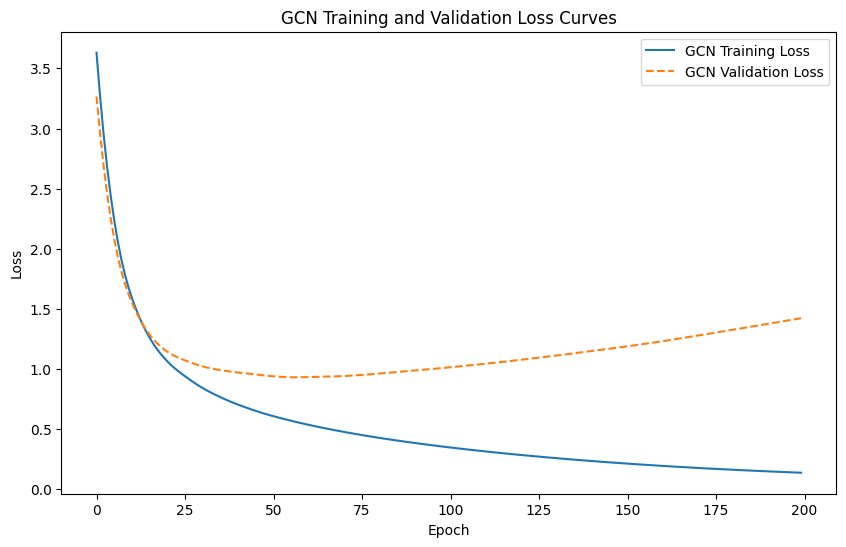

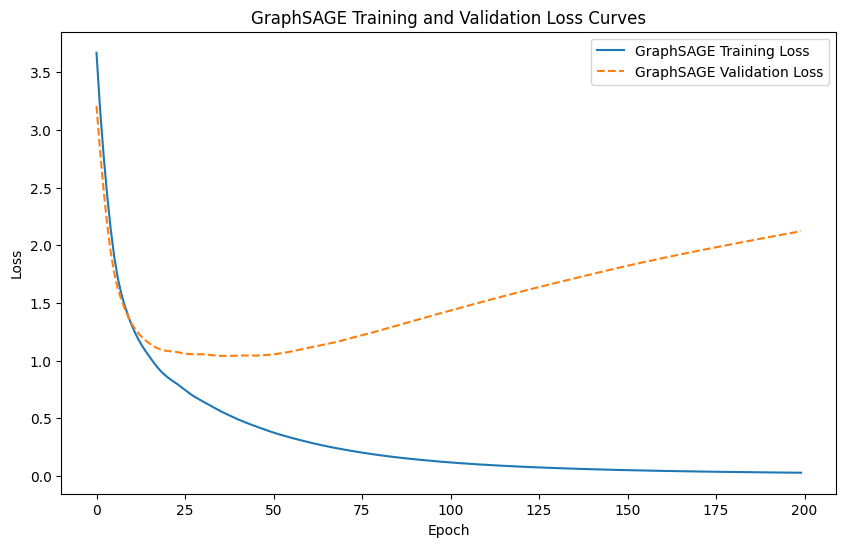

In [20]:


# Initialize lists to store the training and validation loss values for each epoch
train_loss_gcn = []
val_loss_gcn = []
train_loss_sage = []
val_loss_sage = []

def validate(model, data):
    model.eval()
    with torch.no_grad():
        val_mask = data.val_mask.to(device)
        labels = data.y.squeeze().to(device)
        out = model(data.x.to(device), data.edge_index.to(device))
        val_loss = criterion(out[val_mask], labels[val_mask])
    return val_loss.item()

for epoch in range(200):
    loss_gcn = train(gcn_model, optimizer_gcn, subset_graph)
    train_loss_gcn.append(loss_gcn)
    current_val_loss_gcn = validate(gcn_model, subset_graph)
    val_loss_gcn.append(current_val_loss_gcn)

    # Check if the current validation loss is the best we've seen, save model if it is
    if current_val_loss_gcn < best_val_loss_gcn:
        best_val_loss_gcn = current_val_loss_gcn
        best_model_state_gcn = gcn_model.state_dict()

    loss_sage = train(graphsage_model, optimizer_sage, subset_graph)
    train_loss_sage.append(loss_sage)
    current_val_loss_sage = validate(graphsage_model, subset_graph)
    val_loss_sage.append(current_val_loss_sage)

    # Similarly for GraphSAGE
    if current_val_loss_sage < best_val_loss_sage:
        best_val_loss_sage = current_val_loss_sage
        best_model_state_sage = graphsage_model.state_dict()


    if epoch % 10 == 0:
        print(f'Epoch {epoch}, GCN Loss: {loss_gcn:.4f}, GraphSAGE Loss: {loss_sage:.4f}, GCN Val Loss: {val_loss_gcn[-1]:.4f}, GraphSAGE Val Loss: {val_loss_sage[-1]:.4f}')


# Optionally, load the best model state back into the model
gcn_model.load_state_dict(best_model_state_gcn)
graphsage_model.load_state_dict(best_model_state_sage)


def test_model(model, data):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        test_mask = data.test_mask.to(device)
        labels = data.y.squeeze().to(device)
        out = model(data.x.to(device), data.edge_index.to(device))  # Forward pass
        preds = torch.argmax(out, dim=1)[test_mask]  # Only take the predictions from the test mask
        true_labels = labels[test_mask]  # True labels for the test data
    return preds.cpu().numpy(), true_labels.cpu().numpy()

# Plotting the training and validation loss curves for GCN
plt.figure(figsize=(10, 6))
plt.plot(train_loss_gcn, label='GCN Training Loss')
plt.plot(val_loss_gcn, label='GCN Validation Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GCN Training and Validation Loss Curves')
plt.legend()
plt.show()

# Plotting the training and validation loss curves for GraphSAGE
plt.figure(figsize=(10, 6))
plt.plot(train_loss_sage, label='GraphSAGE Training Loss')
plt.plot(val_loss_sage, label='GraphSAGE Validation Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GraphSAGE Training and Validation Loss Curves')
plt.legend()
plt.show()


In [21]:
import torch
import torch.nn.functional as F
from sklearn.metrics import f1_score

def evaluate(model, data, mask):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        eval_mask = mask.to(device)
        labels = data.y.squeeze().to(device)
        logits = model(data.x.to(device), data.edge_index.to(device))  # Forward pass
        preds = logits.argmax(dim=1)  # Get the predicted classes

        # Calculate F1 score
        f1 = f1_score(labels[eval_mask].cpu().numpy(), preds[eval_mask].cpu().numpy(), average='weighted')

        # Calculate log loss using PyTorch's NLLLoss
        log_probs = F.log_softmax(logits[eval_mask], dim=1)
        loss_function = torch.nn.NLLLoss()
        logloss = loss_function(log_probs, labels[eval_mask])

    return f1, logloss.item()

# Example usage
f1_gcn, logloss_gcn = evaluate(gcn_model, subset_graph, subset_graph.val_mask)  # Evaluate GCN on validation set
f1_sage, logloss_sage = evaluate(graphsage_model, subset_graph, subset_graph.val_mask)  # Evaluate GraphSAGE on validation set

print(f"GCN F1 Score: {f1_gcn:.4f}, Log Loss: {logloss_gcn:.4f}")
print(f"GraphSAGE F1 Score: {f1_sage:.4f}, Log Loss: {logloss_sage:.4f}")


GCN F1 Score: 0.7810, Log Loss: 1.4226
GraphSAGE F1 Score: 0.7479, Log Loss: 2.1225


In [22]:
def analyze_category_predictions(true_labels, pred_labels):
    analysis_results = {}
    for category in set(true_labels):
        indices = [i for i, label in enumerate(true_labels) if label == category]

        if not indices:  # Skip categories not present in the subset
            continue

        category_preds = [pred_labels[i] for i in indices]
        correct_preds_count = category_preds.count(category)

        mispredictions = [pred for pred in category_preds if pred != category]
        most_common_misprediction, most_common_misprediction_count = Counter(mispredictions).most_common(1)[0] if mispredictions else ("None", 0)

        analysis_results[category] = {
            'Correct Prediction Percentage': correct_preds_count / len(indices) * 100 if indices else 0,
            'Correct Prediction Count': correct_preds_count,
            'Most Common Misprediction': most_common_misprediction,
            'Misprediction Percentage': most_common_misprediction_count / len(indices) * 100 if mispredictions and indices else 0,
            'Misprediction Count': most_common_misprediction_count,
            'Total Count': len(indices)
        }

    return analysis_results

all_true_labels = [index_product_dict[label.item()] for label in subset_graph.y]

with torch.no_grad():
    gcn_all_logits = gcn_model(subset_graph.x.to(device), subset_graph.edge_index.to(device))
    gcn_all_preds = torch.argmax(gcn_all_logits, dim=1)
    gcn_all_preds = [index_product_dict[pred.item()] for pred in gcn_all_preds]

    sage_all_logits = graphsage_model(subset_graph.x.to(device), subset_graph.edge_index.to(device))
    sage_all_preds = torch.argmax(sage_all_logits, dim=1)
    sage_all_preds = [index_product_dict[pred.item()] for pred in sage_all_preds]

gcn_analysis_all = analyze_category_predictions(all_true_labels, gcn_all_preds)

# Example: Printing analysis results for the GCN model for all nodes
for category, stats in gcn_analysis_all.items():
    print(f"Category: {category}")
    print(f"GCN Correct Predictions: {stats['Correct Prediction Count']} / {stats['Total Count']} ({stats['Correct Prediction Percentage']:.2f}%)")
    print(f"GCN Most Common Misprediction: {stats['Most Common Misprediction']} - {stats['Misprediction Count']} / {stats['Total Count']} ({stats['Misprediction Percentage']:.2f}%)")
    print("-" * 50)


Category: Home & Kitchen
GCN Correct Predictions: 500 / 577 (86.66%)
GCN Most Common Misprediction: Toys & Games - 15 / 577 (2.60%)
--------------------------------------------------
Category: Luxury Beauty
GCN Correct Predictions: 4 / 9 (44.44%)
GCN Most Common Misprediction: Beauty - 2 / 9 (22.22%)
--------------------------------------------------
Category: Industrial & Scientific
GCN Correct Predictions: 32 / 66 (48.48%)
GCN Most Common Misprediction: Health & Personal Care - 12 / 66 (18.18%)
--------------------------------------------------
Category: Patio, Lawn & Garden
GCN Correct Predictions: 191 / 219 (87.21%)
GCN Most Common Misprediction: Sports & Outdoors - 10 / 219 (4.57%)
--------------------------------------------------
Category: Clothing, Shoes & Jewelry
GCN Correct Predictions: 111 / 160 (69.38%)
GCN Most Common Misprediction: Sports & Outdoors - 21 / 160 (13.12%)
--------------------------------------------------
Category: Appliances
GCN Correct Predictions: 7 / 8 (

In [23]:
import pandas as pd

# Convert the analysis results into a list of dictionaries for DataFrame construction
data = []
for category, stats in gcn_analysis_all.items():
    data.append({
        'Category': category,
        'GCN Correct Predictions (%)': f"{stats['Correct Prediction Percentage']:.2f}% ({stats['Correct Prediction Count']}/{stats['Total Count']})",
        'GCN Most Common Misprediction': f"{stats['Most Common Misprediction']} ({stats['Misprediction Percentage']:.2f}% of {stats['Total Count']})",
        'Total Count': stats['Total Count']  # Adding the total count
    })

# Create a DataFrame from the list of dictionaries
df = pd.DataFrame(data)

# Sort the DataFrame by the 'Total Count' column in descending order
df.sort_values('Total Count', ascending=False, inplace=True)

# Optional: drop the 'Total Count' column if you don't want to display it
# df = df.drop(columns=['Total Count'])

# Display the DataFrame
print(df)
df

                     Category GCN Correct Predictions (%)  \
29                      Books          96.33% (2964/3077)   
17                CDs & Vinyl            95.83% (850/887)   
7                Toys & Games            88.71% (668/753)   
22          Sports & Outdoors            83.89% (552/658)   
12     Health & Personal Care            81.36% (489/601)   
0              Home & Kitchen            86.66% (500/577)   
13  Cell Phones & Accessories            95.77% (544/568)   
6                 Movies & TV            89.98% (503/559)   
25                     Beauty            87.95% (467/531)   
24     Grocery & Gourmet Food            92.11% (292/317)   
26               Pet Supplies            95.06% (231/243)   
3        Patio, Lawn & Garden            87.21% (191/219)   
27      Arts, Crafts & Sewing            81.65% (178/218)   
4   Clothing, Shoes & Jewelry            69.38% (111/160)   
10                Electronics             61.15% (85/139)   
19                Video 

,Category,GCN Correct Predictions (%),GCN Most Common Misprediction,Total Count
29,Books,96.33% (2964/3077),CDs & Vinyl (0.65% of 3077),3077
17,CDs & Vinyl,95.83% (850/887),Movies & TV (1.69% of 887),887
7,Toys & Games,88.71% (668/753),Books (3.05% of 753),753
22,Sports & Outdoors,83.89% (552/658),Toys & Games (2.58% of 658),658
12,Health & Personal Care,81.36% (489/601),Beauty (3.33% of 601),601
0,Home & Kitchen,86.66% (500/577),Toys & Games (2.60% of 577),577
13,Cell Phones & Accessories,95.77% (544/568),Books (1.58% of 568),568
6,Movies & TV,89.98% (503/559),Books (3.94% of 559),559
25,Beauty,87.95% (467/531),Health & Personal Care (5.84% of 531),531
24,Grocery & Gourmet Food,92.11% (292/317),Health & Personal Care (2.52% of 317),317


In [24]:
import pandas as pd

# Analyze the predictions made by the GraphSAGE model
sage_analysis_all = analyze_category_predictions(all_true_labels, sage_all_preds)

# Convert the analysis results into a list of dictionaries for DataFrame construction
sage_data = []
for category, stats in sage_analysis_all.items():
    sage_data.append({
        'Category': category,
        'GraphSAGE Correct Predictions (%)': f"{stats['Correct Prediction Percentage']:.2f}% ({stats['Correct Prediction Count']}/{stats['Total Count']})",
        'GraphSAGE Most Common Misprediction': f"{stats['Most Common Misprediction']} ({stats['Misprediction Percentage']:.2f}% of {stats['Total Count']})",
        'Total Count': stats['Total Count']  # Adding the total count
    })

# Create a DataFrame from the list of dictionaries
sage_df = pd.DataFrame(sage_data)

# Sort the DataFrame by the 'Total Count' column in descending order
sage_df.sort_values('Total Count', ascending=False, inplace=True)

# Display the DataFrame
print(sage_df)
sage_df

                     Category GraphSAGE Correct Predictions (%)  \
29                      Books                95.55% (2940/3077)   
17                CDs & Vinyl                  97.18% (862/887)   
7                Toys & Games                  87.78% (661/753)   
22          Sports & Outdoors                  83.43% (549/658)   
12     Health & Personal Care                  83.03% (499/601)   
0              Home & Kitchen                  84.92% (490/577)   
13  Cell Phones & Accessories                  94.37% (536/568)   
6                 Movies & TV                  88.37% (494/559)   
25                     Beauty                  89.64% (476/531)   
24     Grocery & Gourmet Food                  93.69% (297/317)   
26               Pet Supplies                  90.95% (221/243)   
3        Patio, Lawn & Garden                  78.54% (172/219)   
27      Arts, Crafts & Sewing                  81.19% (177/218)   
4   Clothing, Shoes & Jewelry                  77.50% (124/160

,Category,GraphSAGE Correct Predictions (%),GraphSAGE Most Common Misprediction,Total Count
29,Books,95.55% (2940/3077),CDs & Vinyl (0.75% of 3077),3077
17,CDs & Vinyl,97.18% (862/887),Books (1.24% of 887),887
7,Toys & Games,87.78% (661/753),Books (2.66% of 753),753
22,Sports & Outdoors,83.43% (549/658),"Clothing, Shoes & Jewelry (2.89% of 658)",658
12,Health & Personal Care,83.03% (499/601),Beauty (2.33% of 601),601
0,Home & Kitchen,84.92% (490/577),Sports & Outdoors (2.95% of 577),577
13,Cell Phones & Accessories,94.37% (536/568),Books (2.99% of 568),568
6,Movies & TV,88.37% (494/559),Books (6.08% of 559),559
25,Beauty,89.64% (476/531),Health & Personal Care (4.90% of 531),531
24,Grocery & Gourmet Food,93.69% (297/317),Health & Personal Care (1.58% of 317),317


In [25]:
pd.concat([df, sage_df.drop(columns=['Category'])], axis=1).drop(columns=['Total Count'])


# df.columns = ['Product Category'] + df.columns[1:].tolist()


,Category,GCN Correct Predictions (%),GCN Most Common Misprediction,GraphSAGE Correct Predictions (%),GraphSAGE Most Common Misprediction
29,Books,96.33% (2964/3077),CDs & Vinyl (0.65% of 3077),95.55% (2940/3077),CDs & Vinyl (0.75% of 3077)
17,CDs & Vinyl,95.83% (850/887),Movies & TV (1.69% of 887),97.18% (862/887),Books (1.24% of 887)
7,Toys & Games,88.71% (668/753),Books (3.05% of 753),87.78% (661/753),Books (2.66% of 753)
22,Sports & Outdoors,83.89% (552/658),Toys & Games (2.58% of 658),83.43% (549/658),"Clothing, Shoes & Jewelry (2.89% of 658)"
12,Health & Personal Care,81.36% (489/601),Beauty (3.33% of 601),83.03% (499/601),Beauty (2.33% of 601)
0,Home & Kitchen,86.66% (500/577),Toys & Games (2.60% of 577),84.92% (490/577),Sports & Outdoors (2.95% of 577)
13,Cell Phones & Accessories,95.77% (544/568),Books (1.58% of 568),94.37% (536/568),Books (2.99% of 568)
6,Movies & TV,89.98% (503/559),Books (3.94% of 559),88.37% (494/559),Books (6.08% of 559)
25,Beauty,87.95% (467/531),Health & Personal Care (5.84% of 531),89.64% (476/531),Health & Personal Care (4.90% of 531)
24,Grocery & Gourmet Food,92.11% (292/317),Health & Personal Care (2.52% of 317),93.69% (297/317),Health & Personal Care (1.58% of 317)


In [26]:
# Load trained models (assuming they are already trained and loaded into gcn_model and graphsage_model)
gcn_model.eval()
graphsage_model.eval()

with torch.no_grad():
    gcn_embeddings = gcn_model(subset_graph.x.to(device), subset_graph.edge_index.to(device), return_embeds=True)
    graphsage_embeddings = graphsage_model(subset_graph.x.to(device), subset_graph.edge_index.to(device), return_embeds=True)


In [27]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity matrices
gcn_similarity_matrix = cosine_similarity(gcn_embeddings.cpu().numpy())
graphsage_similarity_matrix = cosine_similarity(graphsage_embeddings.cpu().numpy())

# Example usage: Find the top-k most similar items to a given product node
product_idx = 123  # Replace with the index of the product node
top_k = 6

# For GCN embeddings
top_k_similar_indices_gcn = np.argsort(-gcn_similarity_matrix[product_idx])[:top_k]
print(f"Top {top_k} similar products to product {product_idx} according to GCN:")
print(top_k_similar_indices_gcn)

# For GraphSAGE embeddings
top_k_similar_indices_sage = np.argsort(-graphsage_similarity_matrix[product_idx])[:top_k]
print(f"Top {top_k} similar products to product {product_idx} according to GraphSAGE:")
print(top_k_similar_indices_sage)


Top 6 similar products to product 123 according to GCN:
[ 123 8380 4236 8527 5663 2805]
Top 6 similar products to product 123 according to GraphSAGE:
[ 123 8380 8726  108 4788 6962]


In [28]:
node_asin_dict

{0: 'B00902X3L2',
 1: 'B000FW4BGM',
 2: 'B001NTYWFQ',
 3: 'B003DTLNVA',
 4: 'B00KFTCE28',
 5: '1609949684',
 6: 'B003I211JQ',
 7: 'B001ECQ4TY',
 8: 'B004MDMA72',
 9: 'B00HRTGUOW',
 10: 'B00004SYOP',
 11: 'B003C3UTGM',
 12: 'B00IMPM8OQ',
 13: '0156005549',
 14: '044020562X',
 15: 'B004OIAR70',
 16: '1580082777',
 17: 'B003GIKNPA',
 18: '0679892737',
 19: 'B00DE1CL18',
 20: 'B004ZMTSS4',
 21: '030795790X',
 22: '1467948209',
 23: '0805066748',
 24: 'B003U2SS3G',
 25: 'B003KSXVOG',
 26: 'B0054EXG6M',
 27: 'B004173R76',
 28: 'B00000263K',
 29: 'B00074H6O2',
 30: 'B000002ITW',
 31: 'B00004XR4U',
 32: 'B00AOCFPP4',
 33: '0800871863',
 34: '0310205824',
 35: 'B003YITRZY',
 36: 'B000AA303E',
 37: 'B0019J4GTW',
 38: 'B00B97OIQK',
 39: '0763610852',
 40: 'B000069KHZ',
 41: 'B0028CX8FW',
 42: '0316206938',
 43: '0375866914',
 44: '0538453052',
 45: '0976998122',
 46: '0324055757',
 47: '111814838X',
 48: 'B007X5173Y',
 49: 'B00HOGRITE',
 50: '0071771336',
 51: '1437726801',
 52: 'B00JAIGRY6',
 53

In [29]:
list(top_k_similar_indices_gcn)

[123, 8380, 4236, 8527, 5663, 2805]

In [30]:
[ node_asin_dict[x] for x in list(top_k_similar_indices_gcn) ]

['B00BV1P6GK',
 'B005NCDI36',
 'B00I2KAUZU',
 'B007AR266M',
 'B00EVEMMI4',
 '0956789331']





6" Handheld Brass Telescope with Wooden Box - Pirate Navigation



In [31]:
# Funko POP Television: Adventure Time Marceline Vinyl Figure


# Adventure Time 5" Finn with Accessories

# Funko My Little Pony: DJ Pon-3 Vinyl Figure

# My Little Pony: Twilight Sparkle


# Plastic Gold Coins 288ct With 24 Pirate Themed tatoos

# Handheld Brass Telescope with Wooden Box - Pirate Navigation

In [32]:
list(top_k_similar_indices_sage)

[123, 8380, 8726, 108, 4788, 6962]

In [33]:
[ node_asin_dict[x] for x in list(top_k_similar_indices_sage) ]

['B00BV1P6GK',
 'B005NCDI36',
 'B001BHSKCG',
 'B004S6BRAY',
 'B00I1AUI80',
 '1629143340']

### Section 4: Experimenting with Aggregations
In this section, we experiment with different aggregation functions within the GraphSAGE model to understand their impact on model performance. Aggregation functions determine how node features are combined from neighboring nodes, which can significantly affect the learning process. We will test mean, sum, and max aggregation functions and evaluate their effects on training and validation performance.

#### Step 1: Define the GraphSAGE Model with Custom Aggregation
We modify the GraphSAGE model to accept an aggregation function as a parameter. This allows us to easily switch between different aggregation strategies and observe their effects on the model's performance.

#### Step 2: Train and Evaluate the Model with Different Aggregations
We define a function to train and evaluate the GraphSAGE model with a specified aggregation function. This function trains the model, computes the loss, and evaluates the validation accuracy at regular intervals. By comparing these metrics, we can determine the effectiveness of each aggregation strategy.

#### Step 3: Training Curve Comparison
To visualize the impact of different aggregation functions, we plot the training and validation loss curves for each aggregation strategy (mean, sum, max). This helps us understand how each aggregation function influences the convergence and performance of the model over time.

#### Step 4: Analyze Category Predictions
We further analyze the model's predictions by evaluating the accuracy of category predictions. We assess the accuracy of the model's category predictions by comparing the predicted labels with the true labels. This helps us understand the model's effectiveness in classifying products into their respective categories.

In [34]:
# Section 3.2

In [35]:
from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, agg_func='mean'):
        super(GraphSAGE, self).__init__()
        self.agg_func = agg_func
        self.conv1 = SAGEConv(in_channels, hidden_channels, self.agg_func)
        self.conv2 = SAGEConv(hidden_channels, out_channels, self.agg_func)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        return torch.log_softmax(x, dim=1)


In [36]:
def train_evaluate(agg_func, device_to_use=None):
    device_to_use = device_to_use or device
    model = GraphSAGE(
        in_channels=subset_graph.num_features,
        hidden_channels=64,
        out_channels=dataset.num_classes,
        agg_func=agg_func
    ).to(device_to_use)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(100):
        model.train()
        optimizer.zero_grad()
        train_mask = subset_graph.train_mask.to(device_to_use)
        train_labels = subset_graph.y.squeeze().to(device_to_use)
        out = model(subset_graph.x.to(device_to_use), subset_graph.edge_index.to(device_to_use))
        loss = criterion(out[train_mask], train_labels[train_mask])
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            model.eval()
            with torch.no_grad():
                val_mask = subset_graph.val_mask.to(device_to_use)
                val_labels = subset_graph.y.squeeze().to(device_to_use)
                preds = out.argmax(dim=1)
                correct = (preds[val_mask] == val_labels[val_mask]).sum()
                acc = int(correct) / int(val_mask.sum())
                print(f'Epoch: {epoch}, Loss: {loss.item():.4f}, Val Acc: {acc:.4f}')

    return acc


aggregations = ['mean', 'sum', 'max']

for agg in aggregations:
    aggregation_device = get_pyg_device_for_aggr(agg)
    print(f'\nTesting with {agg} aggregation:')
    print(f'Device for {agg} aggregation: {aggregation_device}')
    acc = train_evaluate(agg, aggregation_device)
    print(f'Validation Accuracy with {agg} aggregation: {acc:.4f}\n')



Testing with mean aggregation:
Device for mean aggregation: mps
Epoch: 0, Loss: 3.8095, Val Acc: 0.1030
Epoch: 10, Loss: 1.3058, Val Acc: 0.6765
Epoch: 20, Loss: 0.8611, Val Acc: 0.7490
Epoch: 30, Loss: 0.6409, Val Acc: 0.7570
Epoch: 40, Loss: 0.4849, Val Acc: 0.7615
Epoch: 50, Loss: 0.3725, Val Acc: 0.7650
Epoch: 60, Loss: 0.2868, Val Acc: 0.7625
Epoch: 70, Loss: 0.2222, Val Acc: 0.7650
Epoch: 80, Loss: 0.1737, Val Acc: 0.7640
Epoch: 90, Loss: 0.1375, Val Acc: 0.7610
Validation Accuracy with mean aggregation: 0.7610


Testing with sum aggregation:
Device for sum aggregation: mps
Epoch: 0, Loss: 5.7803, Val Acc: 0.0105
Epoch: 10, Loss: 1.3350, Val Acc: 0.7015
Epoch: 20, Loss: 0.9391, Val Acc: 0.7335
Epoch: 30, Loss: 0.6940, Val Acc: 0.7545
Epoch: 40, Loss: 0.5304, Val Acc: 0.7625
Epoch: 50, Loss: 0.4162, Val Acc: 0.7650
Epoch: 60, Loss: 0.3345, Val Acc: 0.7735
Epoch: 70, Loss: 0.2712, Val Acc: 0.7705
Epoch: 80, Loss: 0.2218, Val Acc: 0.7705
Epoch: 90, Loss: 0.1836, Val Acc: 0.7695
Val

In [37]:
# Training curve comparison

Epoch 0, Mean Agg Loss: 3.8055, Sum Agg Loss: 7.0146, Max Agg Loss: 4.1408
Epoch 10, Mean Agg Loss: 1.3464, Sum Agg Loss: 1.3848, Max Agg Loss: 1.5485
Epoch 20, Mean Agg Loss: 0.8793, Sum Agg Loss: 0.9718, Max Agg Loss: 0.9870
Epoch 30, Mean Agg Loss: 0.6413, Sum Agg Loss: 0.7264, Max Agg Loss: 0.7230
Epoch 40, Mean Agg Loss: 0.4850, Sum Agg Loss: 0.5693, Max Agg Loss: 0.5547
Epoch 50, Mean Agg Loss: 0.3724, Sum Agg Loss: 0.4545, Max Agg Loss: 0.4333
Epoch 60, Mean Agg Loss: 0.2872, Sum Agg Loss: 0.3682, Max Agg Loss: 0.3410
Epoch 70, Mean Agg Loss: 0.2240, Sum Agg Loss: 0.3022, Max Agg Loss: 0.2696
Epoch 80, Mean Agg Loss: 0.1762, Sum Agg Loss: 0.2511, Max Agg Loss: 0.2163
Epoch 90, Mean Agg Loss: 0.1408, Sum Agg Loss: 0.2103, Max Agg Loss: 0.1765
Epoch 100, Mean Agg Loss: 0.1139, Sum Agg Loss: 0.1774, Max Agg Loss: 0.1458
Epoch 110, Mean Agg Loss: 0.0933, Sum Agg Loss: 0.1508, Max Agg Loss: 0.1219
Epoch 120, Mean Agg Loss: 0.0774, Sum Agg Loss: 0.1292, Max Agg Loss: 0.1030
Epoch 130,

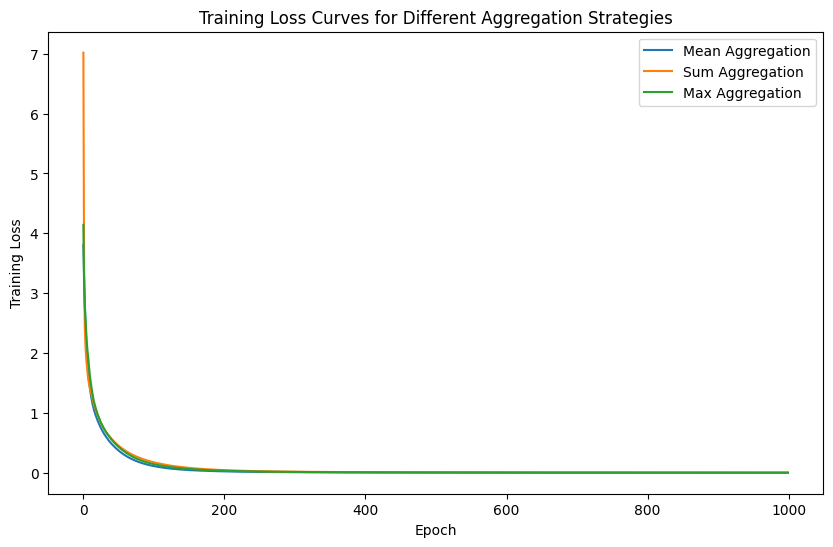

In [38]:
import matplotlib.pyplot as plt

def train_model(model, data, optimizer, criterion):
    model.train()  # Set the model to training mode
    optimizer.zero_grad()  # Clear gradients
    model_device = next(model.parameters()).device
    train_mask = data.train_mask.to(model_device)
    labels = data.y.squeeze().to(model_device)

    out = model(data.x.to(model_device), data.edge_index.to(model_device))  # Forward pass
    loss = criterion(out[train_mask], labels[train_mask])  # Calculate loss only on the training mask
    loss.backward()  # Backpropagate the loss
    optimizer.step()  # Update model parameters

    return loss.item()  # Return the loss value

# Assuming GraphSAGE model is defined with an 'agg_func' parameter to specify the aggregation function
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, agg_func='mean'):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr=agg_func)  # First GraphSAGE layer with specified aggregation
        self.conv2 = SAGEConv(hidden_channels, out_channels, aggr=agg_func)  # Second GraphSAGE layer with specified aggregation

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Create models with different aggregation functions
model_mean = GraphSAGE(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes, agg_func='mean').to(get_pyg_device_for_aggr('mean'))
model_sum = GraphSAGE(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes, agg_func='add').to(get_pyg_device_for_aggr('add'))  # Use 'add' for sum aggregation
model_max = GraphSAGE(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes, agg_func='max').to(get_pyg_device_for_aggr('max'))

# Create separate optimizers for each model
optimizer_mean = torch.optim.Adam(model_mean.parameters(), lr=0.01)
optimizer_sum = torch.optim.Adam(model_sum.parameters(), lr=0.01)
optimizer_max = torch.optim.Adam(model_max.parameters(), lr=0.01)

criterion = torch.nn.CrossEntropyLoss()

# Training loops for different aggregation strategies
losses_mean_agg, losses_sum_agg, losses_max_agg = [], [], []

for epoch in range(1000):
    loss_mean = train_model(model_mean, subset_graph, optimizer_mean, criterion)
    losses_mean_agg.append(loss_mean)

    loss_sum = train_model(model_sum, subset_graph, optimizer_sum, criterion)
    losses_sum_agg.append(loss_sum)

    loss_max = train_model(model_max, subset_graph, optimizer_max, criterion)
    losses_max_agg.append(loss_max)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Mean Agg Loss: {loss_mean:.4f}, Sum Agg Loss: {loss_sum:.4f}, Max Agg Loss: {loss_max:.4f}")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(losses_mean_agg, label='Mean Aggregation')
plt.plot(losses_sum_agg, label='Sum Aggregation')
plt.plot(losses_max_agg, label='Max Aggregation')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curves for Different Aggregation Strategies')
plt.legend()
plt.show()


Epoch 0, Train Loss: 4.0255, Val Loss: 3.4963
Epoch 10, Train Loss: 1.3513, Val Loss: 1.3660
Epoch 20, Train Loss: 0.8726, Val Loss: 1.0958
Epoch 30, Train Loss: 0.6476, Val Loss: 1.0461
Epoch 40, Train Loss: 0.4957, Val Loss: 1.0407
Epoch 50, Train Loss: 0.3847, Val Loss: 1.0522
Epoch 60, Train Loss: 0.2994, Val Loss: 1.1050
Epoch 70, Train Loss: 0.2354, Val Loss: 1.1793
Epoch 80, Train Loss: 0.1871, Val Loss: 1.2620
Epoch 90, Train Loss: 0.1509, Val Loss: 1.3468
Epoch 100, Train Loss: 0.1233, Val Loss: 1.4282
Epoch 110, Train Loss: 0.1021, Val Loss: 1.5113
Epoch 120, Train Loss: 0.0859, Val Loss: 1.5908
Epoch 130, Train Loss: 0.0730, Val Loss: 1.6676
Epoch 140, Train Loss: 0.0627, Val Loss: 1.7404
Epoch 150, Train Loss: 0.0543, Val Loss: 1.8087
Epoch 160, Train Loss: 0.0473, Val Loss: 1.8753
Epoch 170, Train Loss: 0.0415, Val Loss: 1.9409
Epoch 180, Train Loss: 0.0367, Val Loss: 2.0045
Epoch 190, Train Loss: 0.0327, Val Loss: 2.0669
Epoch 0, Train Loss: 4.9179, Val Loss: 2.6896
Epoch

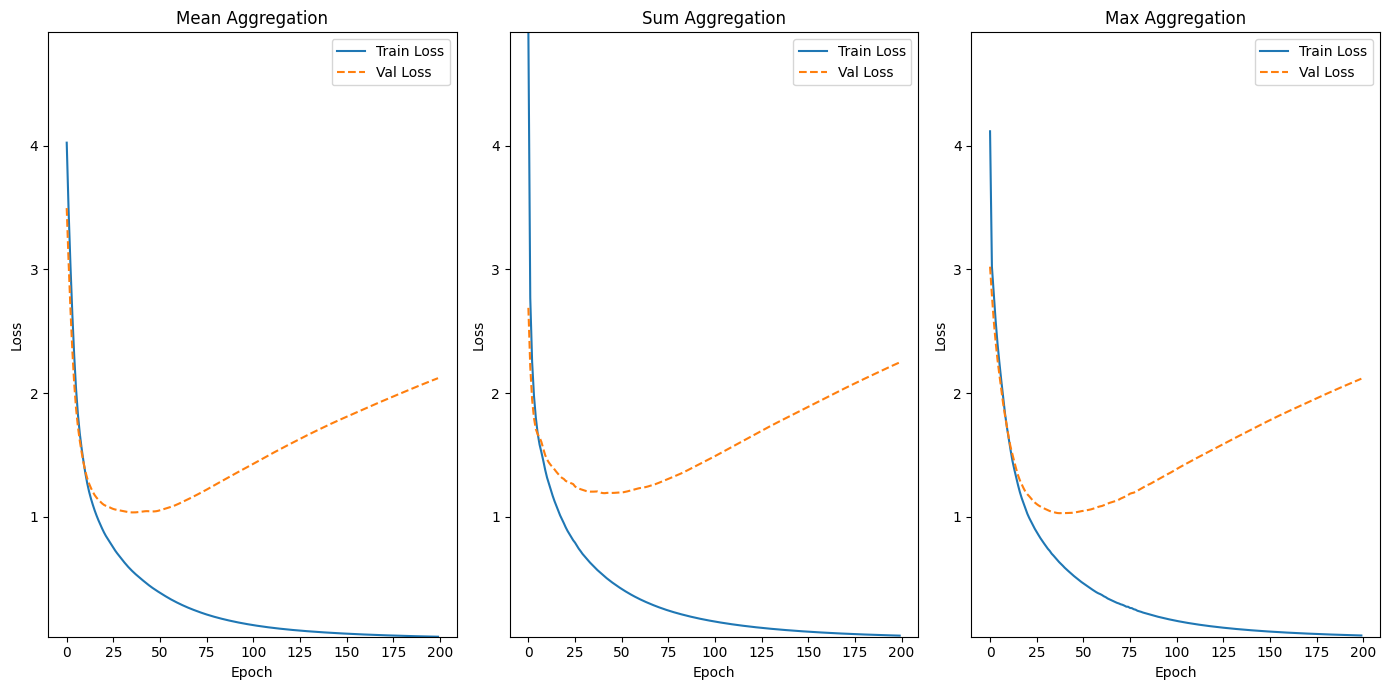

In [39]:
import matplotlib.pyplot as plt

import torch
from torch_geometric.data import Data
from torch_geometric.utils import sort_edge_index, subgraph



class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, agg_func='mean'):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr=agg_func)  # First GraphSAGE layer with specified aggregation
        self.conv2 = SAGEConv(hidden_channels, out_channels, aggr=agg_func)  # Second GraphSAGE layer with specified aggregation

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


def evaluate_model(model, data, criterion):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        model_device = next(model.parameters()).device
        val_mask = data.val_mask.to(model_device)
        labels = data.y.squeeze().to(model_device)
        out = model(data.x.to(model_device), data.edge_index.to(model_device))  # Forward pass
        val_loss = criterion(out[val_mask], labels[val_mask])  # Calculate loss on the validation mask
    return val_loss.item()

# Training and evaluation loop
def train_and_evaluate(model, data, optimizer, criterion, epochs):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        train_loss = train_model(model, data, optimizer, criterion)
        val_loss = evaluate_model(model, data, criterion)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

model_mean = GraphSAGE(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes, agg_func='mean').to(get_pyg_device_for_aggr('mean'))
model_sum = GraphSAGE(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes, agg_func='add').to(get_pyg_device_for_aggr('add'))  # Use 'add' for sum aggregation
model_max = GraphSAGE(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes, agg_func='max').to(get_pyg_device_for_aggr('max'))


# Create separate optimizers for each model
optimizer_mean = torch.optim.Adam(model_mean.parameters(), lr=0.01)
optimizer_sum = torch.optim.Adam(model_sum.parameters(), lr=0.01)
optimizer_max = torch.optim.Adam(model_max.parameters(), lr=0.01)


criterion = torch.nn.CrossEntropyLoss()

# Train and evaluate the models
train_losses_mean, val_losses_mean = train_and_evaluate(model_mean, subset_graph, optimizer_mean, criterion, 200)
train_losses_sum, val_losses_sum = train_and_evaluate(model_sum, subset_graph, optimizer_sum, criterion, 200)
train_losses_max, val_losses_max = train_and_evaluate(model_max, subset_graph, optimizer_max, criterion, 200)



# Calculate global minimum and maximum
global_min = min(min(train_losses_mean), min(val_losses_mean), min(train_losses_sum), min(val_losses_sum), min(train_losses_max), min(val_losses_max))
global_max = max(max(train_losses_mean), max(val_losses_mean), max(train_losses_sum), max(val_losses_sum), max(train_losses_max), max(val_losses_max))


# Plotting training and validation loss curves
plt.figure(figsize=(14, 7))

plt.subplot(1, 3, 1)
plt.plot(train_losses_mean, label='Train Loss')
plt.plot(val_losses_mean, label='Val Loss', linestyle='--')
plt.title('Mean Aggregation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(global_min, global_max)  # Set uniform y-axis limits
plt.legend()

# Sum aggregation curves
plt.subplot(1, 3, 2)
plt.plot(train_losses_sum, label='Train Loss')
plt.plot(val_losses_sum, label='Val Loss', linestyle='--')
plt.title('Sum Aggregation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(global_min, global_max)  # Set uniform y-axis limits
plt.legend()

# Max aggregation curves
plt.subplot(1, 3, 3)
plt.plot(train_losses_max, label='Train Loss')
plt.plot(val_losses_max, label='Val Loss', linestyle='--')
plt.title('Max Aggregation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(global_min, global_max)  # Set uniform y-axis limits
plt.legend()


plt.tight_layout()
plt.show()


In [40]:
# Comparing the perfornace of the models

import pandas as pd
from collections import Counter

# Function to perform analysis
def analyze_category_predictions(true_labels, pred_labels):
    analysis_results = {}
    for category in set(true_labels):
        indices = [i for i, label in enumerate(true_labels) if label == category]
        if not indices:
            continue
        category_preds = [pred_labels[i] for i in indices]
        correct_preds_count = category_preds.count(category)
        mispredictions = [pred for pred in category_preds if pred != category]
        most_common_misprediction = Counter(mispredictions).most_common(1)
        most_common_misprediction = most_common_misprediction[0] if most_common_misprediction else ("None", 0)

        analysis_results[category] = {
            'Correct Prediction Percentage': correct_preds_count / len(indices) * 100,
            'Correct Prediction Count': correct_preds_count,
            'Most Common Misprediction': most_common_misprediction[0],
            'Misprediction Percentage': most_common_misprediction[1] / len(indices) * 100,
            'Total Count': len(indices)
        }
    return analysis_results

# Convert to human-readable labels
all_true_labels = [index_product_dict[label.item()] for label in subset_graph.y.squeeze()]

# Get predictions for all models
def get_model_predictions(model, graph):
    model.eval()
    device = next(model.parameters()).device
    model.to(device)
    with torch.no_grad():
        logits = model(graph.x.to(device), graph.edge_index.to(device))
        preds = torch.argmax(logits, dim=1)
        return [index_product_dict[pred.item()] for pred in preds]

# Analyze predictions for all models
mean_preds = get_model_predictions(model_mean, subset_graph)
sum_preds = get_model_predictions(model_sum, subset_graph)
max_preds = get_model_predictions(model_max, subset_graph)

mean_analysis = analyze_category_predictions(all_true_labels, mean_preds)
sum_analysis = analyze_category_predictions(all_true_labels, sum_preds)
max_analysis = analyze_category_predictions(all_true_labels, max_preds)

# Create DataFrames from the analysis
def create_dataframe(analysis_results):
    data = [{
        'Category': category,
        'Correct Predictions (%)': f"{stats['Correct Prediction Percentage']:.2f}% ({stats['Correct Prediction Count']})",
        'Most Common Misprediction': f"{stats['Most Common Misprediction']} ({stats['Misprediction Percentage']:.2f}%)",
        'Total Count': stats['Total Count']
    } for category, stats in analysis_results.items()]
    return pd.DataFrame(data).sort_values('Total Count', ascending=False)

mean_df = create_dataframe(mean_analysis)
sum_df = create_dataframe(sum_analysis)
max_df = create_dataframe(max_analysis)

# Display the DataFrames
print("Mean Aggregation Analysis")
print(mean_df)
print("\nSum Aggregation Analysis")
print(sum_df)
print("\nMax Aggregation Analysis")
print(max_df)


Mean Aggregation Analysis
                     Category Correct Predictions (%)  \
29                      Books           95.71% (2945)   
17                CDs & Vinyl            96.51% (856)   
7                Toys & Games            88.05% (663)   
22          Sports & Outdoors            84.65% (557)   
12     Health & Personal Care            83.19% (500)   
0              Home & Kitchen            84.58% (488)   
13  Cell Phones & Accessories            94.54% (537)   
6                 Movies & TV            88.01% (492)   
25                     Beauty            88.51% (470)   
24     Grocery & Gourmet Food            91.80% (291)   
26               Pet Supplies            89.71% (218)   
3        Patio, Lawn & Garden            78.54% (172)   
27      Arts, Crafts & Sewing            82.57% (180)   
4   Clothing, Shoes & Jewelry            78.12% (125)   
10                Electronics            72.66% (101)   
19                Video Games            83.74% (103)   
9    

In [41]:
# Ensure 'Category' is a column and not an index
mean_df = mean_df.reset_index(drop=True)
sum_df = sum_df.reset_index(drop=True)
max_df = max_df.reset_index(drop=True)

# Merge the dataframes on 'Category' column
comparison_df = pd.merge(mean_df, sum_df, on='Category', suffixes=('_Mean', '_Sum'))
comparison_df = pd.merge(comparison_df, max_df, on='Category')
comparison_df.rename(columns={
    'Correct Predictions (%)': 'Correct Predictions (%)_Max',
    'Most Common Misprediction': 'Most Common Misprediction_Max',
    'Total Count': 'Total Count_Max'
}, inplace=True)

# Order the columns to group by Mean, Sum, Max
column_order = ['Category',
                'Correct Predictions (%)_Mean', 'Most Common Misprediction_Mean',
                'Correct Predictions (%)_Sum', 'Most Common Misprediction_Sum',
                'Correct Predictions (%)_Max', 'Most Common Misprediction_Max',
                'Total Count_Mean']  # You can include the Total Counts for Sum and Max if they differ

# Reindex the DataFrame based on the new column order
comparison_df = comparison_df[column_order]

# Display the combined DataFrame
comparison_df


,Category,Correct Predictions (%)_Mean,Most Common Misprediction_Mean,Correct Predictions (%)_Sum,Most Common Misprediction_Sum,Correct Predictions (%)_Max,Most Common Misprediction_Max,Total Count_Mean
0,Books,95.71% (2945),CDs & Vinyl (0.84%),95.74% (2946),CDs & Vinyl (0.94%),95.16% (2928),CDs & Vinyl (0.88%),3077
1,CDs & Vinyl,96.51% (856),Books (1.58%),96.62% (857),Books (2.03%),96.17% (853),Books (1.58%),887
2,Toys & Games,88.05% (663),Books (3.05%),87.12% (656),Books (3.72%),85.66% (645),Books (4.25%),753
3,Sports & Outdoors,84.65% (557),"Clothing, Shoes & Jewelry (2.74%)",81.61% (537),"Clothing, Shoes & Jewelry (3.65%)",82.83% (545),"Clothing, Shoes & Jewelry (3.50%)",658
4,Health & Personal Care,83.19% (500),Books (2.16%),82.86% (498),Sports & Outdoors (3.16%),82.70% (497),Sports & Outdoors (3.00%),601
5,Home & Kitchen,84.58% (488),Health & Personal Care (3.64%),86.48% (499),Sports & Outdoors (3.12%),84.92% (490),Sports & Outdoors (3.29%),577
6,Cell Phones & Accessories,94.54% (537),Books (2.46%),95.42% (542),Books (2.29%),94.01% (534),Books (3.17%),568
7,Movies & TV,88.01% (492),Books (6.62%),87.30% (488),Books (6.98%),86.23% (482),Books (6.62%),559
8,Beauty,88.51% (470),Health & Personal Care (5.08%),89.83% (477),Health & Personal Care (4.52%),90.40% (480),Health & Personal Care (4.33%),531
9,Grocery & Gourmet Food,91.80% (291),Health & Personal Care (3.15%),92.74% (294),Home & Kitchen (2.21%),92.74% (294),Home & Kitchen (2.84%),317


In [44]:
import torch
from sklearn.metrics import f1_score, log_loss

import torch
import torch.nn.functional as F
from sklearn.metrics import f1_score
import numpy as np

def evaluate(model, data, mask):
    device = next(model.parameters()).device
    model.to(device)
    model.eval()

    # Initialize the loss function for negative log likelihood
    loss_function = torch.nn.NLLLoss()

    with torch.no_grad():
        eval_mask = mask.to(device)
        labels = data.y.squeeze().to(device)
        logits = model(data.x.to(device), data.edge_index.to(device))

        # Convert logits to log probabilities (required by NLLLoss)
        log_probs = F.log_softmax(logits[eval_mask], dim=1)

        # Get the predicted classes for accuracy/F1 calculations
        preds = logits[eval_mask].argmax(dim=1)

        true_labels = labels[eval_mask]

        # Calculate F1 score using true labels and predictions
        f1 = f1_score(true_labels.cpu().numpy(), preds.cpu().numpy(), average='weighted')

        # Calculate negative log likelihood loss
        nll_loss = loss_function(log_probs, true_labels)

        # # Calculate log loss manually for comparison and potential use (this is informational)
        # probabilities = torch.softmax(logits[mask], dim=1).cpu().numpy()
        # logloss_sklearn = log_loss(true_labels.cpu().numpy(), probabilities, labels=np.unique(true_labels.cpu().numpy()))

    return f1, nll_loss.item()


# Define all possible labels explicitly (for example, labels from 0 to 31)
all_labels = list(range(32))  # Adjust this range based on your specific dataset

f1_score_mean, logloss_mean = evaluate(model_mean, subset_graph, subset_graph.val_mask)
print(f"Mean F1 Score: {f1_score_mean:.4f}, Log Loss: {logloss_mean:.4f}" )

f1_score_sum, logloss_sum = evaluate(model_sum, subset_graph, subset_graph.val_mask)
print(f"Sum F1 Score: {f1_score_sum:.4f}, Log Loss: {logloss_sum:.4f}" )

f1_score_max, logloss_max = evaluate(model_max, subset_graph, subset_graph.val_mask)
print(f"Max F1 Score: {f1_score_max:.4f}, Log Loss: {logloss_max:.4f}" )

Mean F1 Score: 0.7405, Log Loss: 2.1209
Sum F1 Score: 0.7381, Log Loss: 2.2485
Max F1 Score: 0.7436, Log Loss: 2.1166


### Section 5: Experimenting with Additional Aggregation Methods and Parameters
In this section, we extend our experimentation with aggregation methods by testing layer-wise aggregations and advanced configurations. By using different combinations of aggregation strategies within the layers of the GraphSAGE model, we aim to identify which configurations yield the best performance.

#### Layer-Wise Aggregation
We experiment with applying different aggregation functions at each layer of the GraphSAGE model. This approach allows us to understand the impact of combining multiple aggregation methods within a single model architecture.

#### Custom Aggregation Configurations
We test several custom configurations:

Sum-Max Aggregation: Applying sum aggregation in the first layer and max aggregation in the second layer.
Mean-Max Aggregation: Applying mean aggregation in the first layer and max aggregation in the second layer.
Multiple Aggregations: Using a combination of 'max', 'sum', and 'mean' aggregations within the layers.
Advanced Aggregations: Incorporating advanced aggregation techniques like Softmax and Std aggregation.
Jumping Knowledge Aggregation
We also implement Jumping Knowledge (JK) networks, which aggregate information from multiple layers to improve the model's representational power.

#### Training and Evaluation
For each aggregation method and configuration, we train the model and evaluate its performance on a validation set. The training involves optimizing the model parameters using the Adam optimizer and computing the loss with CrossEntropyLoss.

#### Performance Comparison
We plot the training and validation loss curves for each aggregation method to compare their performance visually. Additionally, we calculate and compare the F1 scores and log loss values to quantitatively assess the effectiveness of each method.

Epoch 0, Train Loss: 4.8933, Val Loss: 3.0589
Epoch 10, Train Loss: 1.2784, Val Loss: 1.4240
Epoch 20, Train Loss: 0.8512, Val Loss: 1.2176
Epoch 30, Train Loss: 0.6169, Val Loss: 1.1529
Epoch 40, Train Loss: 0.4620, Val Loss: 1.1337
Epoch 50, Train Loss: 0.3539, Val Loss: 1.1612
Epoch 60, Train Loss: 0.2768, Val Loss: 1.2159
Epoch 70, Train Loss: 0.2212, Val Loss: 1.2916
Epoch 80, Train Loss: 0.1800, Val Loss: 1.3791
Epoch 90, Train Loss: 0.1485, Val Loss: 1.4644
Epoch 100, Train Loss: 0.1243, Val Loss: 1.5540
Epoch 110, Train Loss: 0.1051, Val Loss: 1.6416
Epoch 120, Train Loss: 0.0897, Val Loss: 1.7288
Epoch 130, Train Loss: 0.0774, Val Loss: 1.8158
Epoch 140, Train Loss: 0.0674, Val Loss: 1.9003
Epoch 150, Train Loss: 0.0591, Val Loss: 1.9823
Epoch 160, Train Loss: 0.0522, Val Loss: 2.0587
Epoch 170, Train Loss: 0.0464, Val Loss: 2.1319
Epoch 180, Train Loss: 0.0414, Val Loss: 2.2022
Epoch 190, Train Loss: 0.0372, Val Loss: 2.2694


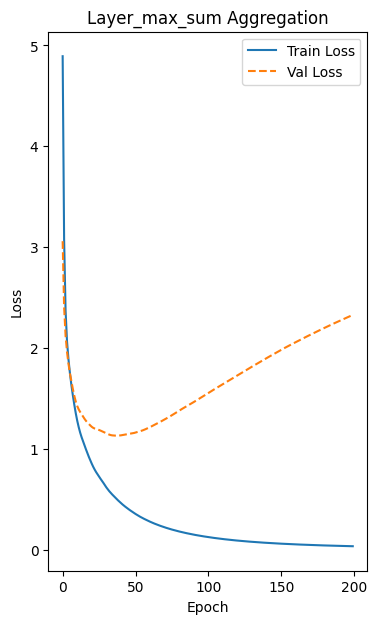

In [45]:
# layer-wise aggregation

import torch
from torch_geometric.nn import SAGEConv

class CustomGraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(CustomGraphSAGE, self).__init__()
        # First layer with mean aggregation
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr='sum')
        # Second layer with max aggregation
        self.conv2 = SAGEConv(hidden_channels, out_channels, aggr='max')


    def forward(self, x, edge_index):
        # Apply the first layer and ReLU activation function
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        # Apply the second layer
        x = self.conv2(x, edge_index)
        return torch.log_softmax(x, dim=1)

# Instantiate the model and move it to the appropriate device
model_layer_max_sum = CustomGraphSAGE(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes).to(get_pyg_device_for_aggr('max'))

# Create an optimizer for the model's parameters
optimizer_layer = torch.optim.Adam(model_layer_max_sum.parameters(), lr=0.01)

# Define the loss criterion
criterion = torch.nn.CrossEntropyLoss()

# Train and evaluate the models
train_losses_layer_max_sum, val_losses_layer_max_sum = train_and_evaluate(model_layer_max_sum, subset_graph, optimizer_layer, criterion, 200)

# Plotting training and validation loss curves
plt.figure(figsize=(14, 7))

# Mean aggregation curves
plt.subplot(1, 3, 1)
plt.plot(train_losses_layer_max_sum, label='Train Loss')
plt.plot(val_losses_layer_max_sum, label='Val Loss', linestyle='--')
plt.title('Layer_max_sum Aggregation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

Epoch 0, Train Loss: 3.9660, Val Loss: 3.2836
Epoch 10, Train Loss: 1.2881, Val Loss: 1.3495
Epoch 20, Train Loss: 0.8691, Val Loss: 1.1308
Epoch 30, Train Loss: 0.6362, Val Loss: 1.0666
Epoch 40, Train Loss: 0.4801, Val Loss: 1.0488
Epoch 50, Train Loss: 0.3654, Val Loss: 1.0619
Epoch 60, Train Loss: 0.2790, Val Loss: 1.1186
Epoch 70, Train Loss: 0.2170, Val Loss: 1.1946
Epoch 80, Train Loss: 0.1712, Val Loss: 1.2774
Epoch 90, Train Loss: 0.1381, Val Loss: 1.3665
Epoch 100, Train Loss: 0.1133, Val Loss: 1.4484
Epoch 110, Train Loss: 0.0939, Val Loss: 1.5275
Epoch 120, Train Loss: 0.0788, Val Loss: 1.6065
Epoch 130, Train Loss: 0.0668, Val Loss: 1.6850
Epoch 140, Train Loss: 0.0574, Val Loss: 1.7612
Epoch 150, Train Loss: 0.0497, Val Loss: 1.8346
Epoch 160, Train Loss: 0.0435, Val Loss: 1.9034
Epoch 170, Train Loss: 0.0384, Val Loss: 1.9690
Epoch 180, Train Loss: 0.0342, Val Loss: 2.0323
Epoch 190, Train Loss: 0.0306, Val Loss: 2.0926


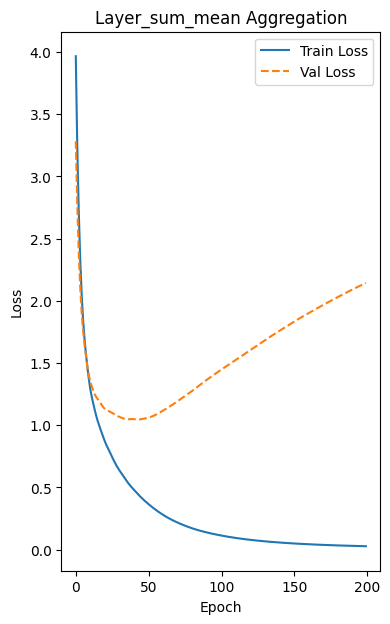

In [46]:
# layer-wise aggregation

import torch
from torch_geometric.nn import SAGEConv

class CustomGraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(CustomGraphSAGE, self).__init__()
        # First layer with mean aggregation
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr='mean')
        # Second layer with max aggregation
        self.conv2 = SAGEConv(hidden_channels, out_channels, aggr='max')


    def forward(self, x, edge_index):
        # Apply the first layer and ReLU activation function
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        # Apply the second layer
        x = self.conv2(x, edge_index)
        return torch.log_softmax(x, dim=1)

# Instantiate the model and move it to the appropriate device
model_layer_sum_mean = CustomGraphSAGE(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes).to(get_pyg_device_for_aggr('max'))

# Create an optimizer for the model's parameters
optimizer_layer = torch.optim.Adam(model_layer_sum_mean.parameters(), lr=0.01)

# Define the loss criterion
criterion = torch.nn.CrossEntropyLoss()

# Train and evaluate the models
train_losses_layer_sum_mean, val_losses_layer_sum_mean = train_and_evaluate(model_layer_sum_mean, subset_graph, optimizer_layer, criterion, 200)

# Plotting training and validation loss curves
plt.figure(figsize=(14, 7))

# Mean aggregation curves
plt.subplot(1, 3, 1)
plt.plot(train_losses_layer_sum_mean, label='Train Loss')
plt.plot(val_losses_layer_sum_mean, label='Val Loss', linestyle='--')
plt.title('Layer_sum_mean Aggregation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

Epoch 0, Train Loss: 3.9237, Val Loss: 3.2412
Epoch 10, Train Loss: 1.2924, Val Loss: 1.3391
Epoch 20, Train Loss: 0.8577, Val Loss: 1.1352
Epoch 30, Train Loss: 0.6232, Val Loss: 1.0784
Epoch 40, Train Loss: 0.4653, Val Loss: 1.0697
Epoch 50, Train Loss: 0.3499, Val Loss: 1.0944
Epoch 60, Train Loss: 0.2684, Val Loss: 1.1421
Epoch 70, Train Loss: 0.2096, Val Loss: 1.2158
Epoch 80, Train Loss: 0.1673, Val Loss: 1.2981
Epoch 90, Train Loss: 0.1362, Val Loss: 1.3811
Epoch 100, Train Loss: 0.1123, Val Loss: 1.4668
Epoch 110, Train Loss: 0.0937, Val Loss: 1.5515
Epoch 120, Train Loss: 0.0789, Val Loss: 1.6321
Epoch 130, Train Loss: 0.0671, Val Loss: 1.7062
Epoch 140, Train Loss: 0.0577, Val Loss: 1.7789
Epoch 150, Train Loss: 0.0499, Val Loss: 1.8510
Epoch 160, Train Loss: 0.0436, Val Loss: 1.9211
Epoch 170, Train Loss: 0.0384, Val Loss: 1.9887
Epoch 180, Train Loss: 0.0341, Val Loss: 2.0532
Epoch 190, Train Loss: 0.0305, Val Loss: 2.1154


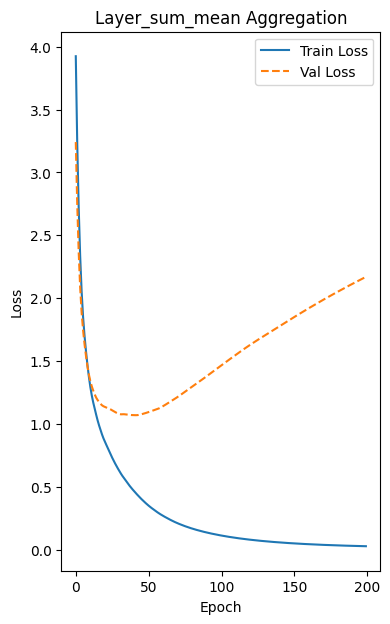

In [47]:
# layer-wise aggregation

import torch
from torch_geometric.nn import SAGEConv

class CustomGraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(CustomGraphSAGE, self).__init__()
        # First layer with mean aggregation
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr='mean')
        # Second layer with max aggregation
        self.conv2 = SAGEConv(hidden_channels, out_channels, aggr='max')


    def forward(self, x, edge_index):
        # Apply the first layer and ReLU activation function
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        # Apply the second layer
        x = self.conv2(x, edge_index)
        return torch.log_softmax(x, dim=1)

# Instantiate the model and move it to the appropriate device
model_layer_sum_mean = CustomGraphSAGE(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes).to(get_pyg_device_for_aggr('max'))

# Create an optimizer for the model's parameters
optimizer_layer = torch.optim.Adam(model_layer_sum_mean.parameters(), lr=0.01)

# Define the loss criterion
criterion = torch.nn.CrossEntropyLoss()

# Train and evaluate the models
train_losses_layer_sum_mean, val_losses_layer_sum_mean = train_and_evaluate(model_layer_sum_mean, subset_graph, optimizer_layer, criterion, 200)

# Plotting training and validation loss curves
plt.figure(figsize=(14, 7))

# Mean aggregation curves
plt.subplot(1, 3, 1)
plt.plot(train_losses_layer_sum_mean, label='Train Loss')
plt.plot(val_losses_layer_sum_mean, label='Val Loss', linestyle='--')
plt.title('Layer_sum_mean Aggregation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

Epoch 0, Train Loss: 4.0011, Val Loss: 2.7462
Epoch 10, Train Loss: 1.1430, Val Loss: 1.3122
Epoch 20, Train Loss: 0.7232, Val Loss: 1.1274
Epoch 30, Train Loss: 0.4915, Val Loss: 1.1078
Epoch 40, Train Loss: 0.3431, Val Loss: 1.1398
Epoch 50, Train Loss: 0.2450, Val Loss: 1.2262
Epoch 60, Train Loss: 0.1809, Val Loss: 1.3422
Epoch 70, Train Loss: 0.1382, Val Loss: 1.4631
Epoch 80, Train Loss: 0.1084, Val Loss: 1.5870
Epoch 90, Train Loss: 0.0867, Val Loss: 1.7065
Epoch 100, Train Loss: 0.0706, Val Loss: 1.8214
Epoch 110, Train Loss: 0.0584, Val Loss: 1.9293
Epoch 120, Train Loss: 0.0490, Val Loss: 2.0296
Epoch 130, Train Loss: 0.0416, Val Loss: 2.1217
Epoch 140, Train Loss: 0.0357, Val Loss: 2.2074
Epoch 150, Train Loss: 0.0310, Val Loss: 2.2899
Epoch 160, Train Loss: 0.0272, Val Loss: 2.3693
Epoch 170, Train Loss: 0.0240, Val Loss: 2.4454
Epoch 180, Train Loss: 0.0215, Val Loss: 2.5178
Epoch 190, Train Loss: 0.0193, Val Loss: 2.5858


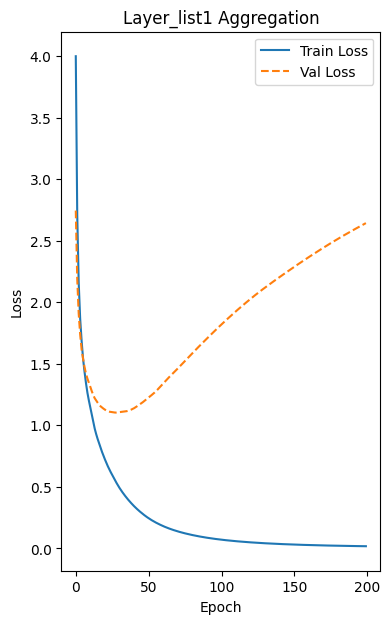

In [50]:
# layer-wise aggregation

import torch
from torch_geometric.nn import SAGEConv

class CustomGraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(CustomGraphSAGE, self).__init__()
        # First layer with mean aggregation
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr=['max', 'sum', 'mean'])
        # Second layer with max aggregation
        self.conv2 = SAGEConv(hidden_channels, out_channels, aggr='mean')


    def forward(self, x, edge_index):
        # Apply the first layer and ReLU activation function
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        # Apply the second layer
        x = self.conv2(x, edge_index)
        return torch.log_softmax(x, dim=1)

# Instantiate the model and move it to the appropriate device
model_layer_list1 = CustomGraphSAGE(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes).to(get_pyg_device_for_aggr(['max', 'sum', 'mean']))

# Create an optimizer for the model's parameters
optimizer_layer = torch.optim.Adam(model_layer_list1.parameters(), lr=0.01)

# Define the loss criterion
criterion = torch.nn.CrossEntropyLoss()

# Train and evaluate the models
train_losses_layer_list1, val_losses_layer_list1 = train_and_evaluate(model_layer_list1, subset_graph, optimizer_layer, criterion, 200)

# Plotting training and validation loss curves
plt.figure(figsize=(14, 7))

# Mean aggregation curves
plt.subplot(1, 3, 1)
plt.plot(train_losses_layer_list1, label='Train Loss')
plt.plot(val_losses_layer_list1, label='Val Loss', linestyle='--')
plt.title('Layer_list1 Aggregation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

/Users/dpatti/miniforge3/envs/gnn_env/lib/python3.11/site-packages/torch_geometric/utils/_scatter.py:102: UserWarning: The operator 'aten::scatter_reduce.two_out' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1742433291615/work/aten/src/ATen/mps/MPSFallback.mm:13.)
  return src.new_zeros(size).scatter_reduce_(


Epoch 0, Train Loss: 3.8767, Val Loss: 2.9835
Epoch 10, Train Loss: 1.5744, Val Loss: 1.5913
Epoch 20, Train Loss: 0.9749, Val Loss: 1.1561
Epoch 30, Train Loss: 0.7136, Val Loss: 1.0503
Epoch 40, Train Loss: 0.5453, Val Loss: 1.0422
Epoch 50, Train Loss: 0.4229, Val Loss: 1.0749
Epoch 60, Train Loss: 0.3300, Val Loss: 1.1220
Epoch 70, Train Loss: 0.2607, Val Loss: 1.1971
Epoch 80, Train Loss: 0.2069, Val Loss: 1.2837
Epoch 90, Train Loss: 0.1659, Val Loss: 1.3739
Epoch 100, Train Loss: 0.1342, Val Loss: 1.4661
Epoch 110, Train Loss: 0.1097, Val Loss: 1.5588
Epoch 120, Train Loss: 0.0906, Val Loss: 1.6498
Epoch 130, Train Loss: 0.0756, Val Loss: 1.7424
Epoch 140, Train Loss: 0.0638, Val Loss: 1.8326
Epoch 150, Train Loss: 0.0544, Val Loss: 1.9170
Epoch 160, Train Loss: 0.0470, Val Loss: 1.9962
Epoch 170, Train Loss: 0.0410, Val Loss: 2.0715
Epoch 180, Train Loss: 0.0361, Val Loss: 2.1424
Epoch 190, Train Loss: 0.0320, Val Loss: 2.2082


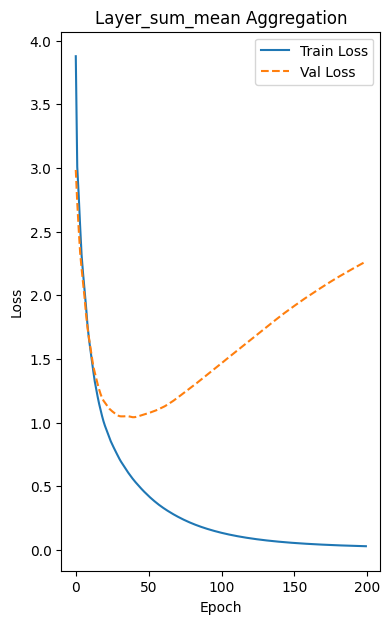

In [51]:
# layer-wise aggregation

import torch
from torch_geometric.nn import SAGEConv

class CustomGraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(CustomGraphSAGE, self).__init__()
        # First layer with mean aggregation
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr=[SoftmaxAggregation(), StdAggregation() ])
        # Second layer with max aggregation
        self.conv2 = SAGEConv(hidden_channels, out_channels, aggr='mean' )


# model_10_layers = GCNWithCustomDropout(subset_graph.num_features, 64, dataset.num_classes, 2, dropout_rate=0.5, aggr=['max', 'sum', 'mean']).to(device)
# model_50_layers = GCNWithCustomDropout(subset_graph.num_features, 64, dataset.num_classes, 2, dropout_rate=0.50, aggr=[SoftmaxAggregation(), StdAggregation() ] ).to(device)


    def forward(self, x, edge_index):
        # Apply the first layer and ReLU activation function
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        # Apply the second layer
        x = self.conv2(x, edge_index)
        return torch.log_softmax(x, dim=1)

# Instantiate the model and move it to the appropriate device
model_layer_list2 = CustomGraphSAGE(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes).to(device)

# Create an optimizer for the model's parameters
optimizer_layer = torch.optim.Adam(model_layer_list2.parameters(), lr=0.01)

# Define the loss criterion
criterion = torch.nn.CrossEntropyLoss()

# Train and evaluate the models
train_losses_layer_list2, val_losses_layer_list2 = train_and_evaluate(model_layer_list2, subset_graph, optimizer_layer, criterion, 200)

# Plotting training and validation loss curves
plt.figure(figsize=(14, 7))

# Mean aggregation curves
plt.subplot(1, 3, 1)
plt.plot(train_losses_layer_list2, label='Train Loss')
plt.plot(val_losses_layer_list2, label='Val Loss', linestyle='--')
plt.title('Layer_sum_mean Aggregation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [52]:
# knowledge jumping

Epoch 0, Train Loss: 4.7229, Val Loss: 4.5762
Epoch 10, Train Loss: 3.5211, Val Loss: 3.4438
Epoch 20, Train Loss: 2.7497, Val Loss: 2.7394
Epoch 30, Train Loss: 2.2812, Val Loss: 2.3247
Epoch 40, Train Loss: 1.9791, Val Loss: 2.0739
Epoch 50, Train Loss: 1.7744, Val Loss: 1.9081
Epoch 60, Train Loss: 1.6299, Val Loss: 1.7967
Epoch 70, Train Loss: 1.5232, Val Loss: 1.7181
Epoch 80, Train Loss: 1.4408, Val Loss: 1.6601
Epoch 90, Train Loss: 1.3743, Val Loss: 1.6141
Epoch 100, Train Loss: 1.3196, Val Loss: 1.5763
Epoch 110, Train Loss: 1.2728, Val Loss: 1.5457
Epoch 120, Train Loss: 1.2306, Val Loss: 1.5190
Epoch 130, Train Loss: 1.1935, Val Loss: 1.4957
Epoch 140, Train Loss: 1.1625, Val Loss: 1.4760
Epoch 150, Train Loss: 1.1352, Val Loss: 1.4584
Epoch 160, Train Loss: 1.1105, Val Loss: 1.4428
Epoch 170, Train Loss: 1.0881, Val Loss: 1.4294
Epoch 180, Train Loss: 1.0683, Val Loss: 1.4182
Epoch 190, Train Loss: 1.0505, Val Loss: 1.4086
Epoch 200, Train Loss: 1.0343, Val Loss: 1.4007
Epo

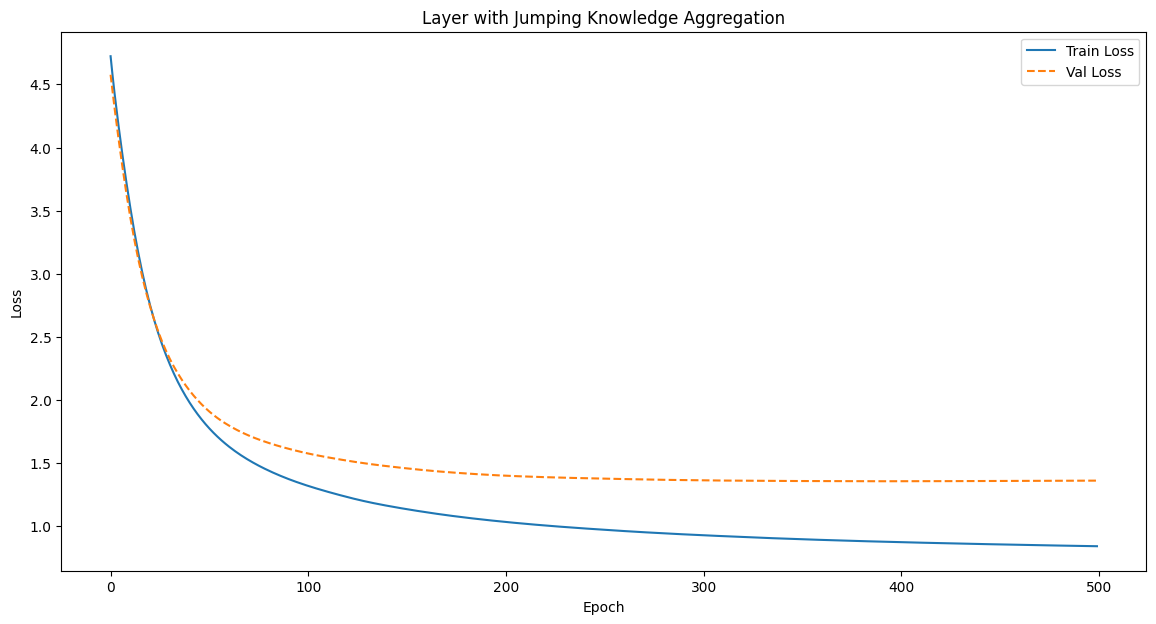

In [53]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, JumpingKnowledge

class CustomGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(CustomGCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

        # Initialize Jumping Knowledge with concatenation mode
        self.jk = JumpingKnowledge(mode='cat')

    def forward(self, x, edge_index):
        # List to save outputs from each layer for JK
        layer_outputs = []

        # First layer
        x1 = self.conv1(x, edge_index)
        x1 = F.relu(x1)
        layer_outputs.append(x1)

        # Second layer
        x2 = self.conv2(x1, edge_index)
        layer_outputs.append(x2)

        # Apply Jumping Knowledge to aggregate layer outputs
        x = self.jk(layer_outputs)

        return x



# Instantiate the model and move it to the appropriate device
model_layer_jk = CustomGCN(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes).to(device)

# Create an optimizer for the model's parameters
optimizer_layer = torch.optim.Adam(model_layer_jk.parameters(), lr=0.01)  # Corrected to use model_layer_jk

# Define the loss criterion
criterion = torch.nn.CrossEntropyLoss()

# Function to train and evaluate the models


def train_and_evaluate(model, data, device, optimizer, criterion, epochs):
    model.to(device)  # Ensure the model is on the correct device
    data = data.to(device)
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Ensure data is on the correct device
        data.x = data.x.to(device)
        data.edge_index = data.edge_index.to(device)
        data.y = data.y.to(device)  # Move labels to GPU if using GPU

        # Forward pass
        output = model(data.x, data.edge_index)

        # Only compute loss on the training mask
        loss = criterion(output[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # Validation phase
        model.eval()
        with torch.no_grad():
            val_output = model(data.x, data.edge_index)
            val_loss = criterion(val_output[data.val_mask], data.y[data.val_mask])

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

    return train_losses, val_losses

# # Dummy data for demonstration
# train_losses_layer_jk = [0.5 - 0.005*i for i in range(200)]  # Example loss data
# val_losses_layer_jk = [0.6 - 0.004*i for i in range(200)]  # Example validation loss data


train_losses_layer_jk, val_losses_layer_jk = train_and_evaluate(model_layer_jk, subset_graph, device, optimizer_layer, criterion, 500)


# Plotting training and validation loss curves
plt.figure(figsize=(14, 7))

# Plot for Layer Jumping Knowledge aggregation
plt.plot(train_losses_layer_jk, label='Train Loss')
plt.plot(val_losses_layer_jk, label='Val Loss', linestyle='--')
plt.title('Layer with Jumping Knowledge Aggregation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [54]:
import torch
from sklearn.metrics import f1_score, log_loss

import torch
import torch.nn.functional as F
from sklearn.metrics import f1_score
import numpy as np

def evaluate(model, data, mask):
    device = next(model.parameters()).device
    model.to(device)
    model.eval()

    # Initialize the loss function for negative log likelihood
    loss_function = torch.nn.NLLLoss()

    with torch.no_grad():
        eval_mask = mask.to(device)
        labels = data.y.squeeze().to(device)
        logits = model(data.x.to(device), data.edge_index.to(device))

        # Convert logits to log probabilities (required by NLLLoss)
        log_probs = F.log_softmax(logits[eval_mask], dim=1)

        # Get the predicted classes for accuracy/F1 calculations
        preds = logits[eval_mask].argmax(dim=1)

        true_labels = labels[eval_mask]

        # Calculate F1 score using true labels and predictions
        f1 = f1_score(true_labels.cpu().numpy(), preds.cpu().numpy(), average='weighted')

        # Calculate negative log likelihood loss
        nll_loss = loss_function(log_probs, true_labels)

        # # Calculate log loss manually for comparison and potential use (this is informational)
        # probabilities = torch.softmax(logits[mask], dim=1).cpu().numpy()
        # logloss_sklearn = log_loss(true_labels.cpu().numpy(), probabilities, labels=np.unique(true_labels.cpu().numpy()))

    return f1, nll_loss.item()
# Mean F1 Score: 0.7406, Log Loss: 2.1215

# Define all possible labels explicitly (for example, labels from 0 to 31)
all_labels = list(range(32))  # Adjust this range based on your specific dataset

f1_score_mean, logloss_mean = evaluate(model_mean, subset_graph, subset_graph.val_mask)
print(f"Mean F1 Score: {f1_score_mean:.4f}, Log Loss: {logloss_mean:.4f}" )

f1_score_sum, logloss_sum = evaluate(model_sum, subset_graph, subset_graph.val_mask)
print(f"Sum F1 Score: {f1_score_sum:.4f}, Log Loss: {logloss_sum:.4f}" )

f1_score_max, logloss_max = evaluate(model_max, subset_graph, subset_graph.val_mask)
print(f"Max F1 Score: {f1_score_max:.4f}, Log Loss: {logloss_max:.4f}" )

f1_score_layer_sum_mean, logloss_layer_sum_mean = evaluate(model_layer_sum_mean, subset_graph, subset_graph.val_mask)
print(f"Layer_sum_mean F1 Score: {f1_score_layer_sum_mean:.4f}, Log Loss: {logloss_layer_sum_mean:.4f}" )

f1_score_layer_max_sum, logloss_layer_max_sum = evaluate(model_layer_max_sum, subset_graph, subset_graph.val_mask)
print(f"Layer_max_sum F1 Score: {f1_score_layer_max_sum:.4f}, Log Loss: {logloss_layer_max_sum:.4f}" )

f1_score_layer_list1, logloss_layer_list1 = evaluate(model_layer_list1, subset_graph, subset_graph.val_mask)
print(f"Layer_list1 F1 Score: {f1_score_layer_list1:.4f}, Log Loss: {logloss_layer_list1:.4f}" )

f1_score_layer_list2, logloss_layer_list2 = evaluate(model_layer_list2, subset_graph, subset_graph.val_mask)
print(f"Layer__list2 F1 Score: {f1_score_layer_list2:.4f}, Log Loss: {logloss_layer_list2:.4f}" )

f1_score_layer_jk, logloss_layer_jk = evaluate(model_layer_jk, subset_graph, subset_graph.val_mask)
print(f"Layer_jk F1 Score: {f1_score_layer_jk:.4f}, Log Loss: {logloss_layer_jk:.4f}" )

Mean F1 Score: 0.7405, Log Loss: 2.1209
Sum F1 Score: 0.7381, Log Loss: 2.2485
Max F1 Score: 0.7436, Log Loss: 2.1166
Layer_sum_mean F1 Score: 0.7447, Log Loss: 2.1692
Layer_max_sum F1 Score: 0.7392, Log Loss: 2.3275
Layer_list1 F1 Score: 0.7318, Log Loss: 2.6444
Layer__list2 F1 Score: 0.7407, Log Loss: 2.2650
Layer_jk F1 Score: 0.6965, Log Loss: 1.3617


### Section 6: Experimenting with Dropout
In this section, we experiment with different dropout rates in the GCN model to understand their impact on model performance. Dropout is a regularization technique that helps prevent overfitting by randomly dropping out neurons during the training process. We aim to explore how various dropout rates affect the training and validation performance of our models.

#### Dropout in GCN
We modify the GCN model to include a dropout layer. This model will apply dropout at each layer, except the final one, to observe its effect on the model's ability to generalize.

#### Training and Evaluation with and without Dropout
We train and evaluate the model with a specific dropout rate and compare its performance against a model without dropout. This comparison helps us understand the benefits and potential drawbacks of using dropout in GCNs.

#### Performance Comparison with Different Dropout Rates
We experiment with different dropout rates (e.g., 0%, 50%, and 85%) to observe how each setting impacts the training and validation loss curves. By plotting these curves, we can visualize the effects of dropout on model convergence and stability.

#### Summarizing Results
Dropout Rates: We experiment with three different dropout rates—0% (no dropout), 50%, and 85%—to evaluate their impact on model performance.
Training and Validation Losses: We plot the training and validation loss curves for each dropout rate to visualize how dropout affects model training and generalization.
Performance Metrics: We calculate precision, recall, and F1 scores for each model to quantitatively assess the effectiveness of dropout in improving model performance.
Confusion Matrix: We generate confusion matrices for each dropout rate to analyze the model's classification accuracy and error distribution.

In [55]:
#dropout


In [56]:
class GCNWithDropout(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout_rate=0.5):
        super(GCNWithDropout, self).__init__()
        self.layers = torch.nn.ModuleList([GCNConv(in_channels, hidden_channels)])
        self.dropout_rate = dropout_rate
        for _ in range(1, num_layers-1):
            self.layers.append(GCNConv(hidden_channels, hidden_channels))
        self.layers.append(GCNConv(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for layer in self.layers[:-1]:
            x = F.relu(layer(x, edge_index))
            x = F.dropout(x, p=self.dropout_rate, training=self.training)
        x = self.layers[-1](x, edge_index)
        return F.log_softmax(x, dim=1)


Epoch 0, Train Loss: 4.0402, Val Loss: 3.6103
Epoch 10, Train Loss: 1.9435, Val Loss: 1.6870
Epoch 20, Train Loss: 1.3729, Val Loss: 1.2356
Epoch 30, Train Loss: 1.1730, Val Loss: 1.0632
Epoch 40, Train Loss: 1.0397, Val Loss: 0.9782
Epoch 50, Train Loss: 0.9719, Val Loss: 0.9241
Epoch 60, Train Loss: 0.8959, Val Loss: 0.9025
Epoch 70, Train Loss: 0.8719, Val Loss: 0.8864
Epoch 80, Train Loss: 0.8398, Val Loss: 0.8747
Epoch 90, Train Loss: 0.7947, Val Loss: 0.8667
Epoch 100, Train Loss: 0.7901, Val Loss: 0.8584
Epoch 110, Train Loss: 0.7662, Val Loss: 0.8526
Epoch 120, Train Loss: 0.7412, Val Loss: 0.8503
Epoch 130, Train Loss: 0.7301, Val Loss: 0.8472
Epoch 140, Train Loss: 0.7356, Val Loss: 0.8463
Epoch 150, Train Loss: 0.7178, Val Loss: 0.8439
Epoch 160, Train Loss: 0.7127, Val Loss: 0.8380
Epoch 170, Train Loss: 0.6876, Val Loss: 0.8435
Epoch 180, Train Loss: 0.7026, Val Loss: 0.8316
Epoch 190, Train Loss: 0.6427, Val Loss: 0.8404


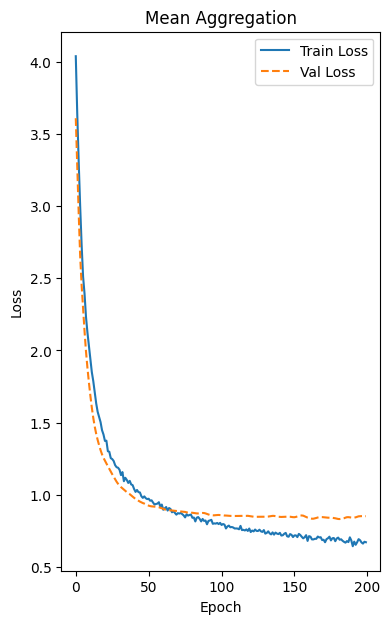

In [57]:
# Instantiate the model and move it to the appropriate device
model_layer = GCNWithDropout(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes).to(device)

# Create an optimizer for the model's parameters
optimizer_layer = torch.optim.Adam(model_layer.parameters(), lr=0.01)

# Define the loss criterion
criterion = torch.nn.CrossEntropyLoss()

def train_and_evaluate(model, data, optimizer, criterion, epochs):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        train_loss = train_model(model, data, optimizer, criterion)
        val_loss = evaluate_model(model, data, criterion)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

# Train and evaluate the models
train_losses_layer, val_losses_layer = train_and_evaluate(model_layer, subset_graph, optimizer_layer, criterion, 200)

# Plotting training and validation loss curves
plt.figure(figsize=(14, 7))

# Mean aggregation curves
plt.subplot(1, 3, 1)
plt.plot(train_losses_layer, label='Train Loss')
plt.plot(val_losses_layer, label='Val Loss', linestyle='--')
plt.title('Mean Aggregation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

Epoch 0, Train Loss: 3.8371, Val Loss: 3.3772
Epoch 10, Train Loss: 1.5287, Val Loss: 1.4980
Epoch 20, Train Loss: 1.0005, Val Loss: 1.1313
Epoch 30, Train Loss: 0.7549, Val Loss: 1.0073
Epoch 40, Train Loss: 0.6055, Val Loss: 0.9822
Epoch 50, Train Loss: 0.4971, Val Loss: 0.9802
Epoch 60, Train Loss: 0.4130, Val Loss: 1.0242
Epoch 70, Train Loss: 0.3457, Val Loss: 1.0901
Epoch 80, Train Loss: 0.2899, Val Loss: 1.1752
Epoch 90, Train Loss: 0.2440, Val Loss: 1.2848
Epoch 100, Train Loss: 0.2062, Val Loss: 1.4044
Epoch 110, Train Loss: 0.1755, Val Loss: 1.5351
Epoch 120, Train Loss: 0.1502, Val Loss: 1.6636
Epoch 130, Train Loss: 0.1319, Val Loss: 1.7975
Epoch 140, Train Loss: 0.1235, Val Loss: 1.9252
Epoch 150, Train Loss: 0.1041, Val Loss: 2.0449
Epoch 160, Train Loss: 0.0896, Val Loss: 2.1750
Epoch 170, Train Loss: 0.0796, Val Loss: 2.3029
Epoch 180, Train Loss: 0.0714, Val Loss: 2.4256
Epoch 190, Train Loss: 0.0638, Val Loss: 2.5480
Epoch 0, Train Loss: 4.2342, Val Loss: 3.5240
Epoch

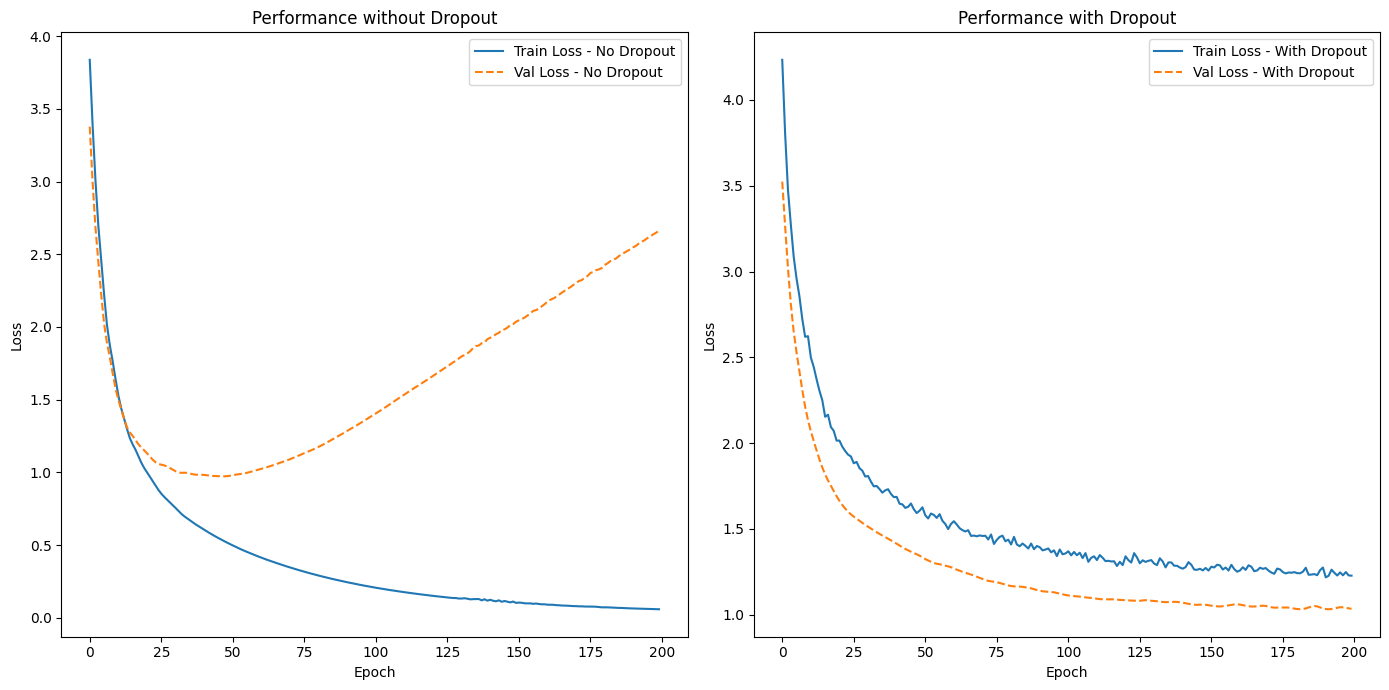

In [58]:
#compare dropout with no-dropout

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCNWithOptionalDropout(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout_rate=0):
        super(GCNWithOptionalDropout, self).__init__()
        self.layers = torch.nn.ModuleList([GCNConv(in_channels, hidden_channels)])
        self.dropout_rate = dropout_rate
        for _ in range(1, num_layers-1):
            self.layers.append(GCNConv(hidden_channels, hidden_channels))
        self.layers.append(GCNConv(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for layer in self.layers[:-1]:
            x = F.relu(layer(x, edge_index))
            if self.dropout_rate > 0:  # Apply dropout only if rate is greater than 0
                x = F.dropout(x, p=self.dropout_rate, training=self.training)
        x = self.layers[-1](x, edge_index)
        return F.log_softmax(x, dim=1)


# Model without dropout
model_no_dropout = GCNWithOptionalDropout(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes, num_layers=3, dropout_rate=0).to(device)

# Model with dropout
model_with_dropout = GCNWithOptionalDropout(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes, num_layers=3, dropout_rate=.8).to(device)

# Optimizers
optimizer_no_dropout = torch.optim.Adam(model_no_dropout.parameters(), lr=0.01)
optimizer_with_dropout = torch.optim.Adam(model_with_dropout.parameters(), lr=0.01)

# Training and evaluating both models
train_losses_no_dropout, val_losses_no_dropout = train_and_evaluate(model_no_dropout, subset_graph, optimizer_no_dropout, criterion, 200)
train_losses_with_dropout, val_losses_with_dropout = train_and_evaluate(model_with_dropout, subset_graph, optimizer_with_dropout, criterion, 200)


plt.figure(figsize=(14, 7))

# Training and validation losses without dropout
plt.subplot(1, 2, 1)
plt.plot(train_losses_no_dropout, label='Train Loss - No Dropout')
plt.plot(val_losses_no_dropout, label='Val Loss - No Dropout', linestyle='--')
plt.title('Performance without Dropout')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Training and validation losses with dropout
plt.subplot(1, 2, 2)
plt.plot(train_losses_with_dropout, label='Train Loss - With Dropout')
plt.plot(val_losses_with_dropout, label='Val Loss - With Dropout', linestyle='--')
plt.title('Performance with Dropout')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Epoch 0, Train Loss: 3.8163, Val Loss: 3.4099
Epoch 10, Train Loss: 1.5679, Val Loss: 1.5466
Epoch 20, Train Loss: 1.0067, Val Loss: 1.1838
Epoch 30, Train Loss: 0.7489, Val Loss: 1.0361
Epoch 40, Train Loss: 0.6026, Val Loss: 1.0046
Epoch 50, Train Loss: 0.4987, Val Loss: 1.0079
Epoch 60, Train Loss: 0.4207, Val Loss: 1.0314
Epoch 70, Train Loss: 0.3581, Val Loss: 1.0821
Epoch 80, Train Loss: 0.3053, Val Loss: 1.1547
Epoch 90, Train Loss: 0.2604, Val Loss: 1.2393
Epoch 100, Train Loss: 0.2222, Val Loss: 1.3371
Epoch 110, Train Loss: 0.1897, Val Loss: 1.4521
Epoch 120, Train Loss: 0.1623, Val Loss: 1.5811
Epoch 130, Train Loss: 0.1396, Val Loss: 1.7294
Epoch 140, Train Loss: 0.1210, Val Loss: 1.8817
Epoch 150, Train Loss: 0.1056, Val Loss: 2.0370
Epoch 160, Train Loss: 0.0909, Val Loss: 2.1973
Epoch 170, Train Loss: 0.0805, Val Loss: 2.3544
Epoch 180, Train Loss: 0.0713, Val Loss: 2.5104
Epoch 190, Train Loss: 0.0637, Val Loss: 2.6668
Epoch 0, Train Loss: 4.1288, Val Loss: 3.5952
Epoch

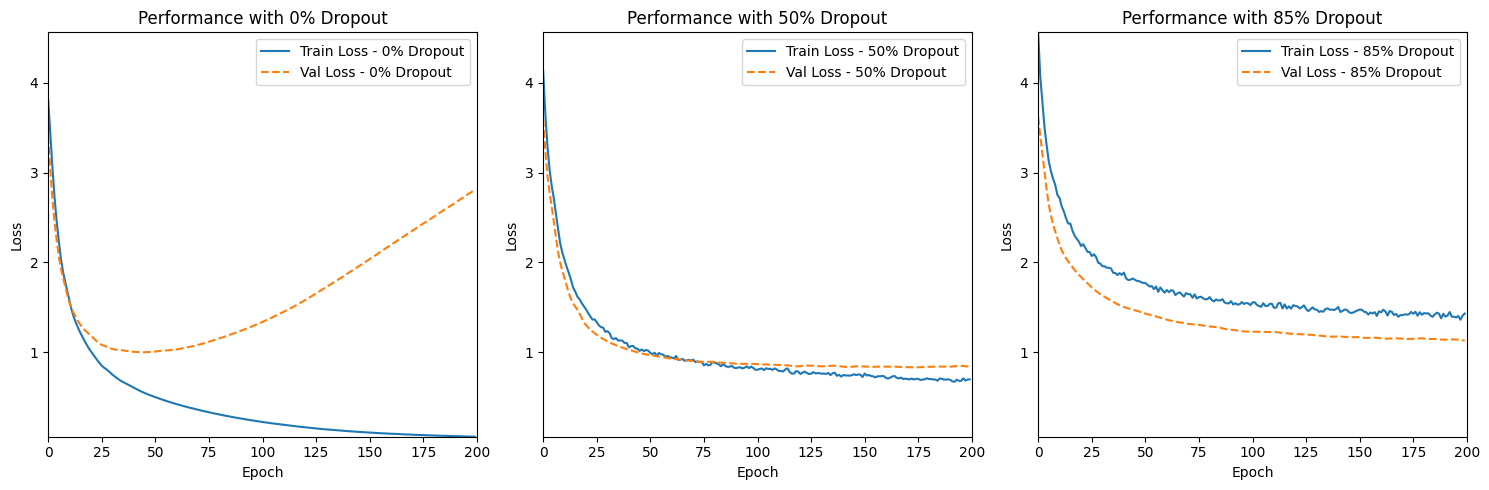

In [59]:
# 3 dropout cases

class GCNWithCustomDropout(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout_rate=0):
        super(GCNWithCustomDropout, self).__init__()
        self.layers = torch.nn.ModuleList([GCNConv(in_channels, hidden_channels)])
        self.dropout_rate = dropout_rate
        for _ in range(1, num_layers-1):
            self.layers.append(GCNConv(hidden_channels, hidden_channels))
        self.layers.append(GCNConv(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for layer in self.layers[:-1]:
            x = F.relu(layer(x, edge_index))
            if self.dropout_rate > 0:  # Apply dropout only if rate is greater than 0
                x = F.dropout(x, p=self.dropout_rate, training=self.training)
        x = self.layers[-1](x, edge_index)
        return F.log_softmax(x, dim=1)


# Models with different dropout rates
model_dropout_0 = GCNWithCustomDropout(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes, dropout_rate=0).to(device)
model_dropout_05 = GCNWithCustomDropout(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes, dropout_rate=0.5).to(device)
model_dropout_085 = GCNWithCustomDropout(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes, dropout_rate=0.85).to(device)

# Optimizers
optimizer_0 = torch.optim.Adam(model_dropout_0.parameters(), lr=0.01)
optimizer_05 = torch.optim.Adam(model_dropout_05.parameters(), lr=0.01)
optimizer_085 = torch.optim.Adam(model_dropout_085.parameters(), lr=0.01)

# Training and evaluating all models
train_losses_0, val_losses_0 = train_and_evaluate(model_dropout_0, subset_graph, optimizer_0, criterion, 200)
train_losses_05, val_losses_05 = train_and_evaluate(model_dropout_05, subset_graph, optimizer_05, criterion, 200)
train_losses_085, val_losses_085 = train_and_evaluate(model_dropout_085, subset_graph, optimizer_085, criterion, 200)

max_epoch = 200

# Assuming you have data for your plots:
# train_losses_0, val_losses_0, train_losses_05, val_losses_05, train_losses_085, val_losses_085

# Determine common limits for x and y axes
all_losses = train_losses_0 + val_losses_0 + train_losses_05 + val_losses_05 + train_losses_085 + val_losses_085
x_limits = (0, max_epoch)  # replace max_epoch with your actual max epoch
y_limits = (min(all_losses), max(all_losses))

# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Plot for 0% dropout
ax1.plot(train_losses_0, label='Train Loss - 0% Dropout')
ax1.plot(val_losses_0, label='Val Loss - 0% Dropout', linestyle='--')
ax1.set_title('Performance with 0% Dropout')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_xlim(x_limits)
ax1.set_ylim(y_limits)

# Plot for 50% dropout
ax2.plot(train_losses_05, label='Train Loss - 50% Dropout')
ax2.plot(val_losses_05, label='Val Loss - 50% Dropout', linestyle='--')
ax2.set_title('Performance with 50% Dropout')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.set_xlim(x_limits)
ax2.set_ylim(y_limits)

# Plot for 85% dropout
ax3.plot(train_losses_085, label='Train Loss - 85% Dropout')
ax3.plot(val_losses_085, label='Val Loss - 85% Dropout', linestyle='--')
ax3.set_title('Performance with 85% Dropout')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Loss')
ax3.legend()
ax3.set_xlim(x_limits)
ax3.set_ylim(y_limits)

plt.tight_layout()
plt.show()



In [60]:
# Function to get predictions from a model
def get_predictions(model, data):
    model.eval()
    with torch.no_grad():
        out = model(data.x.to(device), data.edge_index.to(device))
        preds = torch.argmax(out, dim=1)
        return [index_product_dict[pred.item()] for pred in preds]

all_true_labels = [index_product_dict[label.item()] for label in subset_graph.y.squeeze()]


# Analyze predictions from models with different dropout rates
predictions_0_dropout = get_predictions(model_dropout_0, subset_graph)
predictions_50_dropout = get_predictions(model_dropout_05, subset_graph)
predictions_85_dropout = get_predictions(model_dropout_085, subset_graph)

# Perform analysis for each dropout rate
analysis_0_dropout = analyze_category_predictions(all_true_labels, predictions_0_dropout)
analysis_50_dropout = analyze_category_predictions(all_true_labels, predictions_50_dropout)
analysis_85_dropout = analyze_category_predictions(all_true_labels, predictions_85_dropout)

# Convert the analysis results into DataFrames
df_0_dropout = create_dataframe(analysis_0_dropout)
df_50_dropout = create_dataframe(analysis_50_dropout)
df_85_dropout = create_dataframe(analysis_85_dropout)

# Merge the DataFrames for comparison
comparison_df = pd.merge(df_0_dropout, df_50_dropout, on='Category', suffixes=('_0', '_50'))
comparison_df = pd.merge(comparison_df, df_85_dropout, on='Category')
comparison_df.rename(columns={
    'Correct Predictions (%)': 'Correct Predictions (%)_85',
    'Most Common Misprediction': 'Most Common Misprediction_85',
    'Total Count': 'Total Count_85'
}, inplace=True)

# Set the desired order for the columns
column_order = ['Category',
                'Correct Predictions (%)_0', 'Most Common Misprediction_0', 'Total Count_0',
                'Correct Predictions (%)_50', 'Most Common Misprediction_50', 'Total Count_50',
                'Correct Predictions (%)_85', 'Most Common Misprediction_85', 'Total Count_85']

# Reindex the DataFrame based on the new column order and display it
comparison_df = comparison_df[column_order]
comparison_df


,Category,Correct Predictions (%)_0,Most Common Misprediction_0,Total Count_0,Correct Predictions (%)_50,Most Common Misprediction_50,Total Count_50,Correct Predictions (%)_85,Most Common Misprediction_85,Total Count_85
0,Books,95.97% (2953),Movies & TV (0.58%),3077,95.48% (2938),CDs & Vinyl (0.88%),3077,94.18% (2898),Toys & Games (1.40%),3077
1,CDs & Vinyl,95.49% (847),Movies & TV (1.69%),887,94.70% (840),Books (2.59%),887,91.09% (808),Sports & Outdoors (4.40%),887
2,Toys & Games,86.72% (653),Books (3.85%),753,86.99% (655),Books (4.12%),753,78.75% (593),Books (10.09%),753
3,Sports & Outdoors,85.26% (561),"Clothing, Shoes & Jewelry (2.89%)",658,79.48% (523),Toys & Games (5.32%),658,77.51% (510),Toys & Games (6.84%),658
4,Health & Personal Care,82.03% (493),Beauty (4.16%),601,70.22% (422),Beauty (10.48%),601,53.74% (323),Beauty (19.47%),601
5,Home & Kitchen,88.56% (511),Toys & Games (1.91%),577,80.94% (467),Toys & Games (4.85%),577,63.26% (365),Sports & Outdoors (14.38%),577
6,Cell Phones & Accessories,93.66% (532),Books (1.76%),568,96.30% (547),Books (0.88%),568,94.19% (535),Books (2.46%),568
7,Movies & TV,91.06% (509),Books (3.58%),559,82.65% (462),Books (8.77%),559,65.12% (364),Books (20.04%),559
8,Beauty,87.01% (462),Health & Personal Care (5.08%),531,85.12% (452),Health & Personal Care (7.91%),531,83.05% (441),Health & Personal Care (9.23%),531
9,Grocery & Gourmet Food,92.43% (293),Health & Personal Care (1.89%),317,85.80% (272),Health & Personal Care (5.99%),317,65.93% (209),Health & Personal Care (14.20%),317


In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

def test_model(model, data):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        out = model(data.x.to(device), data.edge_index.to(device))  # Forward pass
        preds = torch.argmax(out, dim=1)[data.test_mask]  # Only take the predictions from the test mask
        true_labels = data.y[data.test_mask]  # True labels for the test data
    return preds.cpu().numpy(), true_labels.cpu().numpy()

# Assuming the model is already trained and test_data is properly configured
predictions, true_labels = test_model(model_dropout_05, subset_graph)

# Calculate precision, recall, and F1 score
precision = precision_score(true_labels, predictions, average='weighted')
recall = recall_score(true_labels, predictions, average='weighted')
f1 = f1_score(true_labels, predictions, average='weighted')

# Compute the confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Display the metrics
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot confusion matrix
plt.figure(figsize=(10, 8))
plot_confusion_matrix(cm, 'Confusion Matrix')
plt.show()


In [ ]:
from torch_geometric.loader import DataLoader
#
# Create the test dataset by filtering out the test nodes
test_data = subset_graph.clone()  # Clone the graph data to preserve the original graph
test_data.x = subset_graph.x[subset_graph.test_mask]  # Node features for test set
test_data.edge_index = subset_graph.edge_index  # Edge index is typically the same for the test set
test_data.y = subset_graph.y[subset_graph.test_mask]  # Labels for the test set

# Make sure to adjust edge_index to only include edges from the test set nodes if necessary

# Now you can use test_data to get predictions from your models



In [ ]:
# Assuming test_data is prepared with the correct test mask and device setup

# Test and evaluate each model
preds_0, labels_0 = test_model(model_dropout_0, subset_graph)
preds_05, labels_05 = test_model(model_dropout_05, subset_graph)
preds_085, labels_085 = test_model(model_dropout_085, subset_graph)

# Compute metrics for each model
precision_0 = precision_score(labels_0, preds_0, average='weighted')
recall_0 = recall_score(labels_0, preds_0, average='weighted')
f1_0 = f1_score(labels_0, preds_0, average='weighted')
cm_0 = confusion_matrix(labels_0, preds_0)

precision_05 = precision_score(labels_05, preds_05, average='weighted')
recall_05 = recall_score(labels_05, preds_05, average='weighted')
f1_05 = f1_score(labels_05, preds_05, average='weighted')
cm_05 = confusion_matrix(labels_05, preds_05)

precision_085 = precision_score(labels_085, preds_085, average='weighted')
recall_085 = recall_score(labels_085, preds_085, average='weighted')
f1_085 = f1_score(labels_085, preds_085, average='weighted')
cm_085 = confusion_matrix(labels_085, preds_085)

# Print metrics for 0% Dropout
print("0% Dropout:")
print(f"Precision: {precision_0:.4f}, Recall: {recall_0:.4f}, F1 Score: {f1_0:.4f}")
plot_confusion_matrix(cm_0, 'Confusion Matrix - 0% Dropout')
plt.show()

# Print metrics for 50% Dropout
print("50% Dropout:")
print(f"Precision: {precision_05:.4f}, Recall: {recall_05:.4f}, F1 Score: {f1_05:.4f}")
plot_confusion_matrix(cm_05, 'Confusion Matrix - 50% Dropout')
plt.show()

# Print metrics for 85% Dropout
print("85% Dropout:")
print(f"Precision: {precision_085:.4f}, Recall: {recall_085:.4f}, F1 Score: {f1_085:.4f}")
plot_confusion_matrix(cm_085, 'Confusion Matrix - 85% Dropout')
plt.show()


In [ ]:
# learning rate, depth

### Section 7: Experimenting with Model Depth
In this section, we experiment with the depth of the GCN by varying the number of layers in the model. Model depth can significantly impact the learning capacity and generalization ability of neural networks. We aim to explore how different depths affect the training and validation performance of our models.

#### Variable Depth in GCN
We modify the GCN model to accept a variable number of layers. This flexibility allows us to create models with different depths and evaluate their performance on the same dataset.

#### Training and Evaluation with Different Depths
We initialize three models with varying depths:

2 Layers: A shallow model with one hidden layer.
10 Layers: A moderately deep model with multiple hidden layers.
50 Layers: A very deep model with many hidden layers.
Each model is trained and evaluated using the same training and validation procedures to ensure a fair comparison.

#### Performance Comparison
We compare the training and validation loss curves for each model depth to understand how increasing the number of layers affects the model's ability to learn and generalize. By plotting these curves, we can visualize the impact of model depth on convergence and stability.

#### Summary of Results
Model Depths: We experiment with three different depths—2 layers, 10 layers, and 50 layers—to evaluate their impact on model performance.
Training and Validation Losses: We plot the training and validation loss curves for each model depth to visualize how the number of layers affects the learning process.
Performance Metrics: We calculate and compare the training and validation losses to assess the effectiveness of each model depth.

In [ ]:
class GCNWithVariableDepth(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2):
        super(GCNWithVariableDepth, self).__init__()
        self.layers = torch.nn.ModuleList()
        # Base layer
        self.layers.append(GCNConv(in_channels, hidden_channels))
        # Hidden layers
        for _ in range(num_layers - 2):
            self.layers.append(GCNConv(hidden_channels, hidden_channels))
        # Output layer
        self.layers.append(GCNConv(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for layer in self.layers[:-1]:
            x = F.relu(layer(x, edge_index))
        x = self.layers[-1](x, edge_index)
        return F.log_softmax(x, dim=1)


In [ ]:
# Initialize models with different depths
model_2_layers = GCNWithVariableDepth(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes, num_layers=2).to(device)
model_10_layers = GCNWithVariableDepth(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes, num_layers=5).to(device)
model_50_layers = GCNWithVariableDepth(in_channels=subset_graph.num_features, hidden_channels=64, out_channels=dataset.num_classes, num_layers=20).to(device)

optimizer_2 = torch.optim.Adam(model_2_layers.parameters(), lr=0.01)
optimizer_10 = torch.optim.Adam(model_10_layers.parameters(), lr=0.01)
optimizer_50 = torch.optim.Adam(model_50_layers.parameters(), lr=0.01)


In [ ]:
# Example training and evaluation function
import torch
import torch.nn.functional as F

def train_and_evaluate(model, data, device, optimizer, criterion, epochs):
    model.to(device)  # Ensure the model is on the correct device
    data = data.to(device)
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Ensure data is on the correct device
        data.x = data.x.to(device)
        data.edge_index = data.edge_index.to(device)
        data.y = data.y.to(device)  # Move labels to GPU if using GPU

        # Forward pass
        output = model(data.x, data.edge_index)

        # Only compute loss on the training mask
        loss = criterion(output[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # Validation phase
        model.eval()
        with torch.no_grad():
            val_output = model(data.x, data.edge_index)
            val_loss = criterion(val_output[data.val_mask], data.y[data.val_mask])

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

    return train_losses, val_losses




In [ ]:
# Assuming 'train_and_evaluate' is defined to include training and validation
train_and_evaluate(model_2_layers, subset_graph, device, epochs=100, optimizer=optimizer_2, criterion=torch.nn.CrossEntropyLoss())
train_and_evaluate(model_10_layers, subset_graph, device, epochs=100, optimizer=optimizer_10, criterion=torch.nn.CrossEntropyLoss())
train_and_evaluate(model_50_layers, subset_graph, device, epochs=100, optimizer=optimizer_50, criterion=torch.nn.CrossEntropyLoss())


In [ ]:
import torch
import torch.nn.functional as F

def train_and_evaluate(model, data, device, optimizer, criterion, epochs):
    model.to(device)  # Ensure the model is on the correct device
    data = data.to(device)
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Move data to the correct device
        data.x = data.x.to(device)
        data.edge_index = data.edge_index.to(device)
        data.y = data.y.to(device)  # Move labels to GPU if using GPU

        # Forward pass and loss calculation on the training mask
        output = model(data.x, data.edge_index)
        train_loss = criterion(output[data.train_mask], data.y[data.train_mask])
        train_loss.backward()
        optimizer.step()

        # Validation loss calculation on the validation mask
        model.eval()
        with torch.no_grad():
            val_output = model(data.x, data.edge_index)
            val_loss = criterion(val_output[data.val_mask], data.y[data.val_mask])

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

    return train_losses, val_losses

# Models with 2, 10, and 50 layers
train_losses_2, val_losses_2 = train_and_evaluate(model_2_layers, subset_graph, device, optimizer_2, torch.nn.CrossEntropyLoss(), 100)
train_losses_10, val_losses_10 = train_and_evaluate(model_10_layers, subset_graph, device, optimizer_10, torch.nn.CrossEntropyLoss(), 100)
train_losses_50, val_losses_50 = train_and_evaluate(model_50_layers, subset_graph, device, optimizer_50, torch.nn.CrossEntropyLoss(), 100)

# Printing training and validation losses for each model configuration
print("Model with 2 layers - Train Losses:", train_losses_2)
print("Model with 2 layers - Validation Losses:", val_losses_2)

print("Model with 10 layers - Train Losses:", train_losses_10)
print("Model with 10 layers - Validation Losses:", val_losses_10)

print("Model with 50 layers - Train Losses:", train_losses_50)
print("Model with 50 layers - Validation Losses:", val_losses_50)


In [ ]:
import matplotlib.pyplot as plt

def plot_losses(train_losses, val_losses, title):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss', linestyle='--')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# Assuming you have already collected the losses in the variables below
# train_losses_2, val_losses_2
# train_losses_10, val_losses_10
# train_losses_50, val_losses_50

plot_losses(train_losses_2, val_losses_2, "Training and Validation Losses for 2 Layers")
plot_losses(train_losses_10, val_losses_10, "Training and Validation Losses for 10 Layers")
plot_losses(train_losses_50, val_losses_50, "Training and Validation Losses for 50 Layers")


### Section 8: Combining Concepts into a Comprehensive Model
In this section, we integrate the various concepts explored earlier, including dropout, aggregation methods, and model depth, into a comprehensive model. This combined approach allows us to leverage the strengths of each technique to optimize our Graph Convolutional Network (GCN) performance.

#### Combined Model Architecture
We utilize a flexible GCN model that incorporates dropout, different aggregation strategies, and variable depth. This model aims to balance the trade-offs between model complexity, regularization, and representational power.

#### Model Initialization
We initialize three models with varying depths (2, 10, and 50 layers) and different dropout rates:

2 Layers: Dropout rate of 50%, Softmax Aggregation.
10 Layers: Dropout rate of 50%, combination of 'max', 'sum', and 'mean' aggregations.
50 Layers: Dropout rate of 50%, advanced aggregation techniques (Softmax and Std Aggregation).
Training and Evaluation
Each model is trained and evaluated using the same dataset and training procedure. We record the training and validation losses and compute performance metrics such as precision, recall, F1 score, and log loss.

#### Performance Comparison
We compare the training and validation loss curves, as well as the performance metrics, for each model to understand the impact of combining dropout, aggregation methods, and varying depths on the overall model performance.

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt

class GCNWithCustomDropout(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers, dropout_rate=0.5):
        super(GCNWithCustomDropout, self).__init__()
        self.layers = torch.nn.ModuleList([GCNConv(in_channels, hidden_channels)])
        for _ in range(1, num_layers-1):
            self.layers.append(GCNConv(hidden_channels, hidden_channels))
        self.layers.append(GCNConv(hidden_channels, out_channels))
        self.dropout_rate = dropout_rate

    def forward(self, x, edge_index):
        for layer in self.layers[:-1]:
            x = F.relu(layer(x, edge_index))
            x = F.dropout(x, p=self.dropout_rate, training=self.training)
        x = self.layers[-1](x, edge_index)
        return F.log_softmax(x, dim=1)

def train_and_evaluate(model, data, device, optimizer, criterion, epochs):
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x.to(device), data.edge_index.to(device))
        loss = criterion(out[data.train_mask], data.y[data.train_mask].to(device))
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            out = model(data.x.to(device), data.edge_index.to(device))
            val_loss = criterion(out[data.val_mask], data.y[data.val_mask].to(device))
            val_losses.append(val_loss.item())
    return train_losses, val_losses

# Initialize models with 50% dropout
device = get_torch_device()
model_2_layers = GCNWithCustomDropout(subset_graph.num_features, 64, dataset.num_classes, 2, dropout_rate=0.5).to(device)
model_10_layers = GCNWithCustomDropout(subset_graph.num_features, 64, dataset.num_classes, 10, dropout_rate=0.5).to(device)
model_50_layers = GCNWithCustomDropout(subset_graph.num_features, 64, dataset.num_classes, 50, dropout_rate=0.5).to(device)

# Create optimizers and criterion
optimizer_2 = torch.optim.Adam(model_2_layers.parameters(), lr=0.01)
optimizer_10 = torch.optim.Adam(model_10_layers.parameters(), lr=0.01)
optimizer_50 = torch.optim.Adam(model_50_layers.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

# Train and evaluate each model
train_losses_2, val_losses_2 = train_and_evaluate(model_2_layers, subset_graph, device, optimizer_2, criterion, 100)
train_losses_10, val_losses_10 = train_and_evaluate(model_10_layers, subset_graph, device, optimizer_10, criterion, 100)
train_losses_50, val_losses_50 = train_and_evaluate(model_50_layers, subset_graph, device, optimizer_50, criterion, 100)

# Plot the losses
plot_losses(train_losses_2, val_losses_2, "Training and Validation Losses for 2 Layers with 50% Dropout")
plot_losses(train_losses_10, val_losses_10, "Training and Validation Losses for 10 Layers with 50% Dropout")
plot_losses(train_losses_50, val_losses_50, "Training and Validation Losses for 50 Layers with 50% Dropout")


In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

class GCNWithCustomDropout(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers, dropout_rate=0.5):
        super(GCNWithCustomDropout, self).__init__()
        self.layers = torch.nn.ModuleList([GCNConv(in_channels, hidden_channels)])
        for _ in range(1, num_layers-1):
            self.layers.append(GCNConv(hidden_channels, hidden_channels))
        self.layers.append(GCNConv(hidden_channels, out_channels))
        self.dropout_rate = dropout_rate

    def forward(self, x, edge_index):
        for layer in self.layers[:-1]:
            x = F.relu(layer(x, edge_index))
            x = F.dropout(x, p=self.dropout_rate, training=self.training)
        x = self.layers[-1](x, edge_index)
        return F.log_softmax(x, dim=1)

def train_and_evaluate(model, data, device, optimizer, criterion, epochs):
    train_losses, val_losses = [], []
    best_metrics = {'precision': 0, 'recall': 0, 'f1_score': 0}

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x.to(device), data.edge_index.to(device))
        loss = criterion(out[data.train_mask], data.y[data.train_mask].to(device))
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            out = model(data.x.to(device), data.edge_index.to(device))
            val_loss = criterion(out[data.val_mask], data.y[data.val_mask].to(device))
            val_losses.append(val_loss.item())

            preds = torch.argmax(out[data.test_mask], dim=1)
            labels = data.y[data.test_mask].to(device)
            precision, recall, f1_score, _ = precision_recall_fscore_support(labels.cpu(), preds.cpu(), average='macro')

            # Update best metrics
            if f1_score > best_metrics['f1_score']:
                best_metrics.update({'precision': precision, 'recall': recall, 'f1_score': f1_score})

    return train_losses, val_losses, best_metrics

def evaluate_predictions(probs, labels):
    epsilon = 1e-9  # Small constant to prevent log(0)
    probs_clamped = torch.clamp(probs, epsilon, 1-epsilon)
    log_probs = torch.log(probs_clamped)
    loss_function = torch.nn.NLLLoss()
    log_loss = loss_function(log_probs, labels)
    return log_loss.item()

def plot_losses(train_losses, val_losses, best_metrics, title):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss', linestyle='--')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.ylim(0, max(max(train_losses), max(val_losses)) + 0.05)  # Adjust y-limit
    plt.legend()
    # plt.text(0.5, 0.1, f'Best Precision: {best_metrics["precision"]:.4f}\n'
    #                    f'Best Recall: {best_metrics["recall"]:.4f}\n'
    #                    f'Best F1 Score: {best_metrics["f1_score"]:.4f}', horizontalalignment='center',
    #          verticalalignment='center', transform=plt.gca().transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
    plt.show()

# Initialize and train models as before, then plot with the new `plot_losses` function including best metrics annotations.

# Initialize models with 50% dropout
device = get_torch_device()
model_2_layers = GCNWithCustomDropout(subset_graph.num_features, 64, dataset.num_classes, 2, dropout_rate=0).to(device)
model_10_layers = GCNWithCustomDropout(subset_graph.num_features, 64, dataset.num_classes, 2, dropout_rate=0.25).to(device)
model_50_layers = GCNWithCustomDropout(subset_graph.num_features, 64, dataset.num_classes, 2, dropout_rate=0.50).to(device)

# Create optimizers and criterion
optimizer_2 = torch.optim.Adam(model_2_layers.parameters(), lr=0.01)
optimizer_10 = torch.optim.Adam(model_10_layers.parameters(), lr=0.01)
optimizer_50 = torch.optim.Adam(model_50_layers.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

# Train and evaluate each model
train_losses_2, val_losses_2, best_metrics_2 = train_and_evaluate(model_2_layers, subset_graph, device, optimizer_2, criterion, 12000)
train_losses_10, val_losses_10 , best_metrics_10= train_and_evaluate(model_10_layers, subset_graph, device, optimizer_10, criterion, 12000)
train_losses_50, val_losses_50 , best_metrics_50 = train_and_evaluate(model_50_layers, subset_graph, device, optimizer_50, criterion, 12000)

# Plot the losses with aligned axes
max_loss = max(max(train_losses_2 + val_losses_2), max(train_losses_10 + val_losses_10), max(train_losses_50 + val_losses_50))


# Plot the losses
plot_losses(train_losses_2, val_losses_2, best_metrics_2, "Training and Validation Losses for 2 Layers with 50% Dropout")
plot_losses(train_losses_10, val_losses_10, best_metrics_10, "Training and Validation Losses for 10 Layers with 50% Dropout")
plot_losses(train_losses_50, val_losses_50, best_metrics_50, "Training and Validation Losses for 50 Layers with 50% Dropout")


In [ ]:
#


In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

def test_model(model, data, device):
    model.eval()
    with torch.no_grad():
        logits = model(data.x.to(device), data.edge_index.to(device))
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        return preds, data.y.to(device), probs

def evaluate_predictions(probs, labels):
    epsilon = 1e-9  # Small constant to prevent log(0)
    probs_clamped = torch.clamp(probs, epsilon, 1-epsilon)
    log_probs = torch.log(probs_clamped)
    loss_function = torch.nn.NLLLoss()
    log_loss = loss_function(log_probs, labels)
    return log_loss.item()


# Testing and evaluation of models
device = get_torch_device()
preds_2, labels_2, probs_2 = test_model(model_2_layers, subset_graph, device)
preds_10, labels_10, probs_10 = test_model(model_10_layers, subset_graph, device)
preds_50, labels_50, probs_50 = test_model(model_50_layers, subset_graph, device)

log_loss_2 = evaluate_predictions(probs_2, labels_2)
log_loss_10 = evaluate_predictions(probs_10, labels_10)
log_loss_50 = evaluate_predictions(probs_50, labels_50)

# Compute metrics for each model
precision_2 = precision_score(labels_2.cpu().numpy(), preds_2.cpu().numpy(), average='weighted')
recall_2 = recall_score(labels_2.cpu().numpy(), preds_2.cpu().numpy(), average='weighted')
f1_2 = f1_score(labels_2.cpu().numpy(), preds_2.cpu().numpy(), average='weighted')
cm_2 = confusion_matrix(labels_2.cpu().numpy(), preds_2.cpu().numpy())

precision_10 = precision_score(labels_10.cpu().numpy(), preds_10.cpu().numpy(), average='weighted')
recall_10 = recall_score(labels_10.cpu().numpy(), preds_10.cpu().numpy(), average='weighted')
f1_10 = f1_score(labels_10.cpu().numpy(), preds_10.cpu().numpy(), average='weighted')
cm_10 = confusion_matrix(labels_10.cpu().numpy(), preds_10.cpu().numpy())

precision_50 = precision_score(labels_50.cpu().numpy(), preds_50.cpu().numpy(), average='weighted')
recall_50 = recall_score(labels_50.cpu().numpy(), preds_50.cpu().numpy(), average='weighted')
f1_50 = f1_score(labels_50.cpu().numpy(), preds_50.cpu().numpy(), average='weighted')
cm_50 = confusion_matrix(labels_50.cpu().numpy(), preds_50.cpu().numpy())

# Print metrics for each model
print("2-Layer:")
print(f"Precision: {precision_2:.4f}, Recall: {recall_2:.4f}, F1 Score: {f1_2:.4f}, Log Loss: {log_loss_2:.4f}")
plot_confusion_matrix(cm_2, 'Confusion Matrix - 0% Dropout')
plt.show()

print("10-Layer:")
print(f"Precision: {precision_10:.4f}, Recall: {recall_10:.4f}, F1 Score: {f1_10:.4f}, Log Loss: {log_loss_10:.4f}")
plot_confusion_matrix(cm_10, 'Confusion Matrix - 50% Dropout')
plt.show()

print("50-Layer:")
print(f"Precision: {precision_50:.4f}, Recall: {recall_50:.4f}, F1 Score: {f1_50:.4f}, Log Loss: {log_loss_50:.4f}")
plot_confusion_matrix(cm_50, 'Confusion Matrix - 85% Dropout')
plt.show()


In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

class GCNWithCustomDropout(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers, dropout_rate=0.5, aggr = 'mean'):
        super(GCNWithCustomDropout, self).__init__()
        self.layers = torch.nn.ModuleList([GCNConv(in_channels, hidden_channels)])
        for _ in range(1, num_layers-1):
            self.layers.append(GCNConv(hidden_channels, hidden_channels))
        self.layers.append(GCNConv(hidden_channels, out_channels))
        self.dropout_rate = dropout_rate

    def forward(self, x, edge_index):
        for layer in self.layers[:-1]:
            x = F.relu(layer(x, edge_index))
            x = F.dropout(x, p=self.dropout_rate, training=self.training)
        x = self.layers[-1](x, edge_index)
        return F.log_softmax(x, dim=1)

def train_and_evaluate(model, data, device, optimizer, criterion, epochs):
    train_losses, val_losses = [], []
    best_metrics = {'precision': 0, 'recall': 0, 'f1_score': 0}

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x.to(device), data.edge_index.to(device))
        loss = criterion(out[data.train_mask], data.y[data.train_mask].to(device))
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            out = model(data.x.to(device), data.edge_index.to(device))
            val_loss = criterion(out[data.val_mask], data.y[data.val_mask].to(device))
            val_losses.append(val_loss.item())

            preds = torch.argmax(out[data.test_mask], dim=1)
            labels = data.y[data.test_mask].to(device)
            precision, recall, f1_score, _ = precision_recall_fscore_support(labels.cpu(), preds.cpu(), average='macro')

            # Update best metrics
            if f1_score > best_metrics['f1_score']:
                best_metrics.update({'precision': precision, 'recall': recall, 'f1_score': f1_score})

    return train_losses, val_losses, best_metrics

def evaluate_predictions(probs, labels):
    epsilon = 1e-9  # Small constant to prevent log(0)
    probs_clamped = torch.clamp(probs, epsilon, 1-epsilon)
    log_probs = torch.log(probs_clamped)
    loss_function = torch.nn.NLLLoss()
    log_loss = loss_function(log_probs, labels)
    return log_loss.item()

def plot_losses(train_losses, val_losses, best_metrics, title):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss', linestyle='--')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.ylim(0, max(max(train_losses), max(val_losses)) + 0.05)  # Adjust y-limit
    plt.legend()
    # plt.text(0.5, 0.1, f'Best Precision: {best_metrics["precision"]:.4f}\n'
    #                    f'Best Recall: {best_metrics["recall"]:.4f}\n'
    #                    f'Best F1 Score: {best_metrics["f1_score"]:.4f}', horizontalalignment='center',
    #          verticalalignment='center', transform=plt.gca().transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
    plt.show()

# Initialize and train models as before, then plot with the new `plot_losses` function including best metrics annotations.

# Initialize models with 50% dropout
device = get_torch_device()
model_2_layers = GCNWithCustomDropout(subset_graph.num_features, 64, dataset.num_classes, 2, dropout_rate=.5, aggr= SoftmaxAggregation()).to(device)
model_10_layers = GCNWithCustomDropout(subset_graph.num_features, 64, dataset.num_classes, 2, dropout_rate=0.5, aggr=['max', 'sum', 'mean']).to(device)
model_50_layers = GCNWithCustomDropout(subset_graph.num_features, 64, dataset.num_classes, 2, dropout_rate=0.50, aggr=[SoftmaxAggregation(), StdAggregation() ] ).to(device)

# Create optimizers and criterion
optimizer_2 = torch.optim.Adam(model_2_layers.parameters(), lr=0.005)
optimizer_10 = torch.optim.Adam(model_10_layers.parameters(), lr=0.005)
optimizer_50 = torch.optim.Adam(model_50_layers.parameters(), lr=0.005)
criterion = torch.nn.CrossEntropyLoss()

# Train and evaluate each model
train_losses_2, val_losses_2, best_metrics_2 = train_and_evaluate(model_2_layers, subset_graph, device, optimizer_2, criterion, 12000)
train_losses_10, val_losses_10 , best_metrics_10= train_and_evaluate(model_10_layers, subset_graph, device, optimizer_10, criterion, 12000)
train_losses_50, val_losses_50 , best_metrics_50 = train_and_evaluate(model_50_layers, subset_graph, device, optimizer_50, criterion, 12000)

# Plot the losses with aligned axes
max_loss = max(max(train_losses_2 + val_losses_2), max(train_losses_10 + val_losses_10), max(train_losses_50 + val_losses_50))


# Plot the losses
plot_losses(train_losses_2, val_losses_2, best_metrics_2, "Training and Validation Losses for 2 Layers with 50% Dropout")
plot_losses(train_losses_10, val_losses_10, best_metrics_10, "Training and Validation Losses for 10 Layers with 50% Dropout")
plot_losses(train_losses_50, val_losses_50, best_metrics_50, "Training and Validation Losses for 50 Layers with 50% Dropout")


In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

def test_model(model, data, device):
    model.eval()
    with torch.no_grad():
        logits = model(data.x.to(device), data.edge_index.to(device))
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        return preds, data.y.to(device), probs

def evaluate_predictions(probs, labels):
    epsilon = 1e-9  # Small constant to prevent log(0)
    probs_clamped = torch.clamp(probs, epsilon, 1-epsilon)
    log_probs = torch.log(probs_clamped)
    loss_function = torch.nn.NLLLoss()
    log_loss = loss_function(log_probs, labels)
    return log_loss.item()


# Testing and evaluation of models
device = get_torch_device()
preds_2, labels_2, probs_2 = test_model(model_2_layers, subset_graph, device)
preds_10, labels_10, probs_10 = test_model(model_10_layers, subset_graph, device)
preds_50, labels_50, probs_50 = test_model(model_50_layers, subset_graph, device)

log_loss_2 = evaluate_predictions(probs_2, labels_2)
log_loss_10 = evaluate_predictions(probs_10, labels_10)
log_loss_50 = evaluate_predictions(probs_50, labels_50)

# Compute metrics for each model
precision_2 = precision_score(labels_2.cpu().numpy(), preds_2.cpu().numpy(), average='weighted')
recall_2 = recall_score(labels_2.cpu().numpy(), preds_2.cpu().numpy(), average='weighted')
f1_2 = f1_score(labels_2.cpu().numpy(), preds_2.cpu().numpy(), average='weighted')
cm_2 = confusion_matrix(labels_2.cpu().numpy(), preds_2.cpu().numpy())

precision_10 = precision_score(labels_10.cpu().numpy(), preds_10.cpu().numpy(), average='weighted')
recall_10 = recall_score(labels_10.cpu().numpy(), preds_10.cpu().numpy(), average='weighted')
f1_10 = f1_score(labels_10.cpu().numpy(), preds_10.cpu().numpy(), average='weighted')
cm_10 = confusion_matrix(labels_10.cpu().numpy(), preds_10.cpu().numpy())

precision_50 = precision_score(labels_50.cpu().numpy(), preds_50.cpu().numpy(), average='weighted')
recall_50 = recall_score(labels_50.cpu().numpy(), preds_50.cpu().numpy(), average='weighted')
f1_50 = f1_score(labels_50.cpu().numpy(), preds_50.cpu().numpy(), average='weighted')
cm_50 = confusion_matrix(labels_50.cpu().numpy(), preds_50.cpu().numpy())

# Print metrics for each model
print("2-Layer:")
print(f"Precision: {precision_2:.4f}, Recall: {recall_2:.4f}, F1 Score: {f1_2:.4f}, Log Loss: {log_loss_2:.4f}")
plot_confusion_matrix(cm_2, 'Confusion Matrix - 0% Dropout')
plt.show()

print("10-Layer:")
print(f"Precision: {precision_10:.4f}, Recall: {recall_10:.4f}, F1 Score: {f1_10:.4f}, Log Loss: {log_loss_10:.4f}")
plot_confusion_matrix(cm_10, 'Confusion Matrix - 50% Dropout')
plt.show()

print("50-Layer:")
print(f"Precision: {precision_50:.4f}, Recall: {recall_50:.4f}, F1 Score: {f1_50:.4f}, Log Loss: {log_loss_50:.4f}")
plot_confusion_matrix(cm_50, 'Confusion Matrix - 85% Dropout')
plt.show()


In [ ]:
# Load trained models (assuming they are already trained and loaded into gcn_model and graphsage_model)
gcn_model.eval()
graphsage_model.eval()

with torch.no_grad():
    embeddings = gcn_model(subset_graph.x.to(device), subset_graph.edge_index.to(device), return_embeds=True)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity matrices
similarity_matrix = cosine_similarity(embeddings.cpu().numpy())

# Example usage: Find the top-k most similar items to a given product node
product_idx = 123  # Replace with the index of the product node
top_k = 6

# For GCN embeddings
top_k_similar_indices = np.argsort(-similarity_matrix[product_idx])[:top_k]
print(f"Top {top_k} similar products to product {product_idx} according to GCN:")
print(top_k_similar_indices)